# Sentiment Analysis and Opinion Mining of FIFA 23 Steam Reviews

This notebook is the complete analysis workflow for the Social Media Computing assignment: **Sentiment Analysis and Opinion Mining of FIFA 23 Steam Reviews**.

The main supervised sentiment label is the Steam recommendation field `voted_up`:

- `True` = Positive sentiment / recommended review
- `False` = Negative sentiment / not recommended review

The notebook is written as a reproducible report pipeline. A new user should be able to install the dependencies, place `dataset/fifa23_steam_reviews.csv` in the repository or upload the CSV in Google Colab, run all cells from top to bottom, and get the cleaned dataset, charts, model results, hypothesis test results, error-analysis samples, and aspect-sentiment outputs.

The workflow covers data loading, cleaning, text preprocessing, EDA, hypothesis testing, TF-IDF feature engineering, traditional supervised ML, transformer sentiment comparison, opinion mining, aspect-based sentiment analysis, final summaries, and exported report files.


## Problem Statement

User reviews on online gaming platforms contain valuable signals about player satisfaction, frustration, and expectations. However, manually reading thousands of reviews is time-consuming and difficult to summarize objectively.

This project applies sentiment analysis and opinion mining techniques to **FIFA 23 Steam reviews** in order to classify review sentiment, identify common opinion words, examine player behavior metadata, and discover which game aspects receive positive or negative feedback.

The main supervised label is `voted_up`, which represents whether a Steam user recommended the game. In this notebook, `voted_up = True` is treated as Positive sentiment and `voted_up = False` is treated as Negative sentiment. The analysis combines exploratory visualization, statistical hypothesis testing, traditional machine learning, transformer-based sentiment prediction, and lightweight aspect-based sentiment analysis to produce outputs that can be used directly in the final report.


## Research Hypotheses

The notebook tests the following hypotheses using cleaned FIFA 23 Steam review data:

**H1: Recent Playtime and Positive Sentiment**

- Alternative hypothesis: Players with higher recent playtime in the last two weeks are more likely to leave positive reviews.
- Null hypothesis: There is no significant difference in recent playtime between positive and negative reviews.

**H2: Number of Games Owned and Negative Sentiment**

- Alternative hypothesis: Players who own more games are more likely to provide negative reviews.
- Null hypothesis: There is no significant difference in the number of games owned between positive and negative reviewers.

**H3: Sentiment Changes Over Time**

- Alternative hypothesis: The proportion of positive and negative reviews changes across review months.
- Null hypothesis: Review sentiment distribution is independent of review month.

**H4: Written Sentiment and Steam Recommendation Agreement**

- Alternative hypothesis: Lexicon-based written sentiment agrees with the Steam `voted_up` recommendation label.
- Null hypothesis: Lexicon-based written sentiment does not meaningfully agree with the Steam `voted_up` recommendation label.


## How to Run or Reuse This Notebook

Use these steps when running the notebook in Google Colab or locally:

1. Keep `requirements.txt` in the repository root. The notebook also works if it is run from the `notebook/` folder.
2. The first setup cell installs dependencies with `!pip install -r requirements.txt`.
3. Keep `dataset/fifa23_steam_reviews.csv` in the repository, upload it to `/content/` in Colab, or place it in one of the Google Drive paths checked by the loader.
4. Select `Runtime > Restart and run all` in Colab.
5. After the notebook finishes, use `outputs/figures/` for PNG charts and `outputs/*.csv` for report tables.

The original CSV is never modified. All derived files are written into the `outputs/` folder.


## 1. Project Setup

This section prepares the runtime environment. It installs dependencies from `requirements.txt`, imports the libraries used throughout the analysis, downloads NLTK resources, sets a fixed random seed, configures chart styling, and creates output folders.

The most important reusable objects created here are `RANDOM_STATE = 42` for reproducibility, `OUTPUT_DIR` and `FIGURE_DIR` for saved artifacts, and `savefig()` for consistent figure export.


In [1]:
# Install project dependencies.
# If requirements.txt is available, use it so everyone gets the same package list.
# If it is missing, install the core packages required by this notebook.
import subprocess
import sys
from pathlib import Path

project_root_for_setup = Path.cwd()
if not (project_root_for_setup / "requirements.txt").exists() and (project_root_for_setup.parent / "requirements.txt").exists():
    project_root_for_setup = project_root_for_setup.parent
requirements_path = project_root_for_setup / "requirements.txt"

if requirements_path.exists():
    print("Installing dependencies from requirements.txt...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)])
else:
    print("requirements.txt not found. Installing core notebook dependencies...")
    fallback_packages = [
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "wordcloud",
        "nltk",
        "scipy",
        "scikit-learn",
        "transformers",
        "torch",
        "tensorflow",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *fallback_packages])

print("Dependency setup complete.")


Installing dependencies from requirements.txt...


Dependency setup complete.


In [2]:
# Import analysis, visualization, NLP, statistics, and machine-learning libraries. The fixed random seed and output folders are also configured here.
import os, re, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk import pos_tag

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for resource in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception as exc:
        print(f"NLTK download warning for {resource}: {exc}")

def savefig(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

print("Setup complete.")


[nltk_data] Error loading stopwords: <urlopen error [WinError 10061]
[nltk_data]     No connection could be made because the target machine
[nltk_data]     actively refused it>


[nltk_data] Error loading wordnet: <urlopen error [WinError 10061] No
[nltk_data]     connection could be made because the target machine
[nltk_data]     actively refused it>


[nltk_data] Error loading omw-1.4: <urlopen error [WinError 10061] No
[nltk_data]     connection could be made because the target machine
[nltk_data]     actively refused it>


[nltk_data] Error loading vader_lexicon: <urlopen error [WinError
[nltk_data]     10061] No connection could be made because the target
[nltk_data]     machine actively refused it>


[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [WinError 10061] No connection could be made because
[nltk_data]     the target machine actively refused it>


Setup complete.


[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [WinError 10061] No connection could be made
[nltk_data]     because the target machine actively refused it>


## 2. Data Loading and Initial Inspection

This section loads the raw Steam reviews and checks whether the dataset matches the expected assignment structure. It displays the shape, column names, data types, first rows, missing values, language counts, sentiment distribution, date ranges, and summary statistics for important metadata columns.

The loader checks `/content`, the current notebook folder, common Google Drive paths, and then manual Colab upload as a fallback.


In [3]:
# Locate and load the FIFA 23 reviews CSV without hard-coding one machine-specific path.
def find_dataset_path():
    candidates = [
        Path("/content/fifa23_steam_reviews.csv"),
        Path("/content/dataset/fifa23_steam_reviews.csv"),
        PROJECT_ROOT / "dataset" / "fifa23_steam_reviews.csv",
        PROJECT_ROOT / "fifa23_steam_reviews.csv",
        Path("dataset/fifa23_steam_reviews.csv"),
        Path("fifa23_steam_reviews.csv"),
        Path("../dataset/fifa23_steam_reviews.csv"),
        Path("/content/drive/MyDrive/fifa23_steam_reviews.csv"),
        Path("/content/drive/MyDrive/Colab Notebooks/fifa23_steam_reviews.csv"),
        Path("/content/drive/MyDrive/Colab Notebooks/Social Media Computing Week 2/fifa23_steam_reviews.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        for path in candidates:
            if path.exists():
                return path
    except Exception as exc:
        print(f"Drive lookup skipped or failed: {exc}")
    try:
        from google.colab import files
        print("Please upload fifa23_steam_reviews.csv")
        uploaded = files.upload()
        return Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError("Could not find fifa23_steam_reviews.csv.") from exc

data_path = find_dataset_path()
df = pd.read_csv(data_path)
if "recieved_for_free" in df.columns and "received_for_free" not in df.columns:
    df["received_for_free"] = df["recieved_for_free"]
df["voted_up"] = df["voted_up"].astype(str).str.strip().str.lower().map({"true": True, "false": False})

print(f"Loaded from: {data_path}")
print("Shape:", df.shape)
display(df.head())
display(pd.DataFrame({"dtype": df.dtypes.astype(str)}))
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
display(df["voted_up"].map({True: "Positive", False: "Negative"}).value_counts(dropna=False).to_frame("review_count"))

created_dates = pd.to_datetime(df["created"], errors="coerce")
last_played_dates = pd.to_datetime(df["author_last_played"], errors="coerce")
print(f"Created date range: {created_dates.min()} to {created_dates.max()}")
print(f"Author last played date range: {last_played_dates.min()} to {last_played_dates.max()}")

summary_cols = ["votes_up", "comment_count", "author_num_games_owned", "author_num_reviews", "author_playtime_forever", "author_playtime_last_two_weeks", "author_playtime_at_review"]
display(df[summary_cols].describe().T)


Loaded from: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\dataset\fifa23_steam_reviews.csv
Shape: (25737, 17)


,id,language,review,created,voted_up,votes_up,comment_count,steam_purchase,recieved_for_free,written_during_early_access,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,received_for_free
0,134539477,english,Mantap,3/12/2023 14:34,True,0,0,True,False,False,9,1,7255,1662,7255,3/12/2023 14:34,False
1,134538118,english,yum,3/12/2023 14:10,True,0,0,True,False,False,18,8,3842,481,3811,3/12/2023 14:40,False
2,134538086,english,i hate all the sweats who never touch grass\n,3/12/2023 14:10,True,0,0,True,False,False,6,1,16462,3041,16462,3/12/2023 13:38,False
3,134537160,english,Fxxk u EAAntiCheat! Fxxk u EA!,3/12/2023 13:53,False,0,0,True,False,False,282,11,4652,13,4652,3/12/2023 13:50,False
4,134536841,english,fifa is the best,3/12/2023 13:47,True,0,0,True,False,False,1,1,9552,261,9544,3/12/2023 13:57,False


,dtype
id,int64
language,str
review,str
created,str
voted_up,bool
votes_up,int64
comment_count,int64
steam_purchase,bool
recieved_for_free,bool
written_during_early_access,bool


,missing_count
review,86
id,0
language,0
created,0
voted_up,0
votes_up,0
comment_count,0
steam_purchase,0
recieved_for_free,0
written_during_early_access,0


,review_count
voted_up,
Positive,14197
Negative,11540


Created date range: 2022-09-29 16:56:00 to 2023-03-12 14:34:00
Author last played date range: 2022-09-27 11:05:00 to 2023-03-12 14:53:00


,count,mean,std,min,25%,50%,75%,max
votes_up,25737.0,2.191126,36.714773,0.0,0.0,0.0,0.0,1897.0
comment_count,25737.0,0.059098,1.053199,0.0,0.0,0.0,0.0,72.0
author_num_games_owned,25737.0,58.070249,170.696836,0.0,7.0,19.0,51.0,8221.0
author_num_reviews,25737.0,6.349613,33.784766,1.0,1.0,2.0,6.0,4310.0
author_playtime_forever,25737.0,9964.320744,11524.811276,5.0,2202.0,6416.0,13717.0,157368.0
author_playtime_last_two_weeks,25737.0,750.215254,1286.305022,0.0,0.0,156.0,1065.0,20157.0
author_playtime_at_review,25737.0,3273.325796,5730.607475,5.0,379.0,1274.0,3652.0,120109.0


## 3. Data Cleaning

This section prepares the dataset for analysis while preserving the original review text.

Rows with missing or empty reviews are removed, exact duplicate review texts are dropped, date columns are parsed, supervised sentiment labels are created from `voted_up`, review length is calculated, and playtime minutes are converted into hours for clearer interpretation.


In [4]:
# Build a cleaned analysis dataframe while preserving the raw loaded dataframe and original CSV file.
df_clean = df.copy()
df_clean["raw_review"] = df_clean["review"].astype("string").fillna("").str.strip()

before_empty = len(df_clean)
df_clean = df_clean[df_clean["raw_review"].str.len() > 0].copy()
after_empty = len(df_clean)

before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="raw_review", keep="first").copy()
after_dup = len(df_clean)

df_clean["created"] = pd.to_datetime(df_clean["created"], errors="coerce")
df_clean["author_last_played"] = pd.to_datetime(df_clean["author_last_played"], errors="coerce")
df_clean = df_clean[df_clean["voted_up"].notna()].copy()
df_clean["sentiment_binary"] = df_clean["voted_up"].astype(int)
df_clean["sentiment_label"] = df_clean["sentiment_binary"].map({1: "Positive", 0: "Negative"})
df_clean["created_month"] = df_clean["created"].dt.to_period("M").dt.to_timestamp()
df_clean["review_length_words"] = df_clean["raw_review"].str.split().str.len()

for col in ["author_playtime_forever", "author_playtime_last_two_weeks", "author_playtime_at_review"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    df_clean[f"{col}_hours"] = df_clean[col] / 60

print(f"Rows before empty review drop: {before_empty:,}")
print(f"Rows after empty review drop: {after_empty:,}")
print(f"Exact duplicate review texts removed: {before_dup - after_dup:,}")
print(f"Final cleaned rows before text preprocessing: {len(df_clean):,}")
display(df_clean[["raw_review", "sentiment_label", "created", "created_month", "review_length_words", "author_playtime_last_two_weeks_hours"]].head())


Rows before empty review drop: 25,737
Rows after empty review drop: 25,633
Exact duplicate review texts removed: 5,583
Final cleaned rows before text preprocessing: 20,050


,raw_review,sentiment_label,created,created_month,review_length_words,author_playtime_last_two_weeks_hours
0,Mantap,Positive,2023-03-12 14:34:00,2023-03-01,1,27.700000
1,yum,Positive,2023-03-12 14:10:00,2023-03-01,1,8.016667
2,i hate all the sweats who never touch grass,Positive,2023-03-12 14:10:00,2023-03-01,9,50.683333
3,Fxxk u EAAntiCheat! Fxxk u EA!,Negative,2023-03-12 13:53:00,2023-03-01,6,0.216667
4,fifa is the best,Positive,2023-03-12 13:47:00,2023-03-01,4,4.350000


## 4. Text Preprocessing

This section converts raw review text into `clean_review`, which is used for word-frequency analysis, TF-IDF features, opinion mining, and traditional ML models.

The cleaning function lowercases text, removes URLs, removes punctuation/special characters and numbers, tokenizes on whitespace, removes stopwords, and lemmatizes words. Negation and sentiment words such as `not`, `no`, `never`, `bad`, and `good` are kept because removing them can flip meaning.


In [5]:
# Create the reusable text-cleaning function. Negations and key sentiment words are intentionally preserved.
lemmatizer = WordNetLemmatizer()
keep_words = {"not", "no", "nor", "never", "bad", "good"}
stop_words = (set(stopwords.words("english")) - keep_words).union({"fifa", "fifa23", "steam", "review", "reviews"})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    return " ".join(lemmatizer.lemmatize(t) for t in tokens)

df_clean["clean_review"] = df_clean["raw_review"].apply(clean_text)
display(df_clean[["raw_review", "clean_review", "sentiment_label"]].sample(5, random_state=RANDOM_STATE))
print("Empty clean reviews:", int((df_clean["clean_review"].str.len() == 0).sum()))


,raw_review,clean_review,sentiment_label
20138,i love it=),love,Positive
24224,Had to fight for my life for the game to open,fight life game open,Negative
20546,I like to torture myself,like torture,Positive
5757,game is fun honestly if you don't like it your probably bad at the game,game fun honestly like probably bad game,Positive
5944,this game is very chill and fun sometimes even funny and relaxing if i get a straight red for winning the ball its a different story,game chill fun sometimes even funny relaxing get straight red winning ball different story,Positive


Empty clean reviews: 593


## 5. Exploratory Data Analysis and Visualizations

This section creates report-ready visual evidence about the FIFA 23 review dataset. The charts describe sentiment balance, review activity over time, review length, player metadata differences by sentiment, frequent words, word clouds, and TF-IDF terms.

Every plot has a clear title, axis labels, and a saved PNG file in `outputs/figures/`.


### 5.1 Sentiment Distribution Charts

Create the basic bar and pie charts for Steam recommendation sentiment.

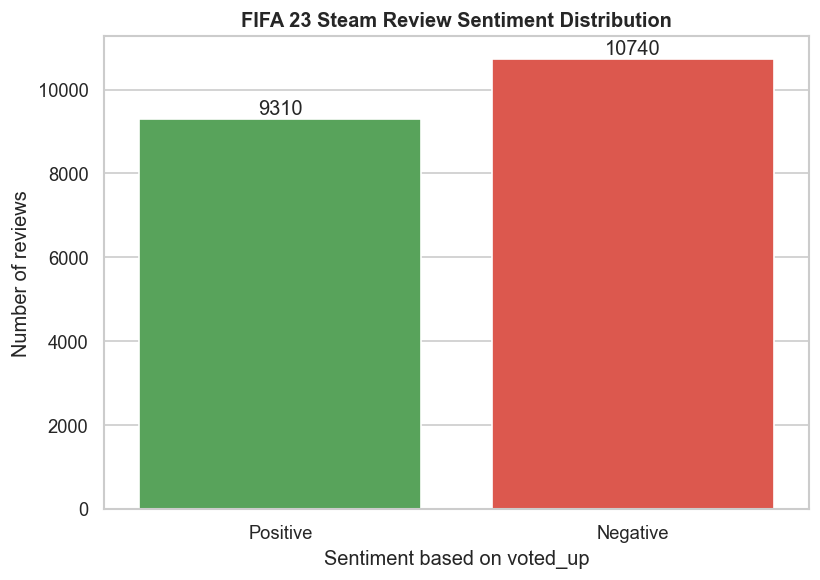

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\01_sentiment_distribution_bar.png


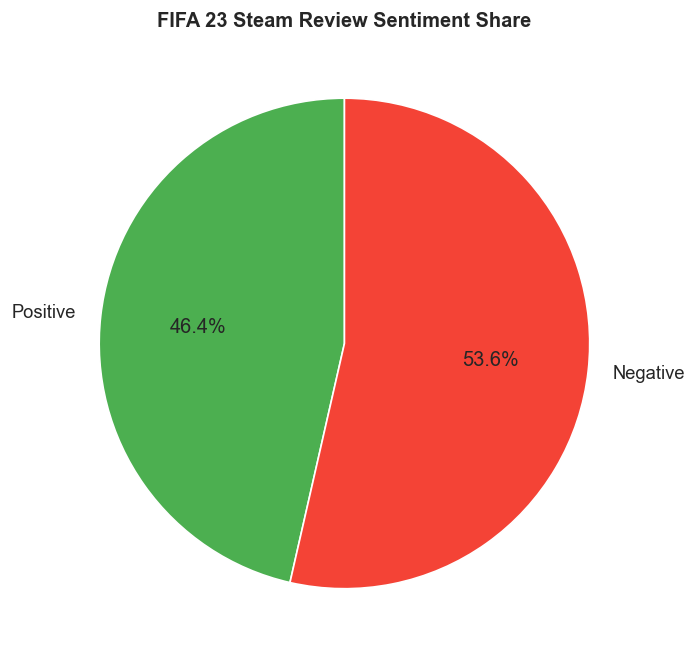

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\02_sentiment_distribution_pie.png


In [6]:
# Generate the first group of EDA figures: sentiment distribution, monthly trends, length distribution, and metadata-by-sentiment plots.
# 1) Bar chart: count positive and negative Steam recommendations.
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x="sentiment_label", order=["Positive", "Negative"], palette=["#4CAF50", "#F44336"])
ax.set(title="FIFA 23 Steam Review Sentiment Distribution", xlabel="Sentiment based on voted_up", ylabel="Number of reviews")
for c in ax.containers: ax.bar_label(c, fmt="%d")
savefig("01_sentiment_distribution_bar.png")

# 2) Pie chart: show the percentage share of each sentiment class.
sentiment_counts = df_clean["sentiment_label"].value_counts().reindex(["Positive", "Negative"])
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#F44336"])
plt.title("FIFA 23 Steam Review Sentiment Share")
savefig("02_sentiment_distribution_pie.png")



### 5.2 Monthly Review and Sentiment Trends

Build the monthly summary table and plot review volume and positive sentiment percentage over time.

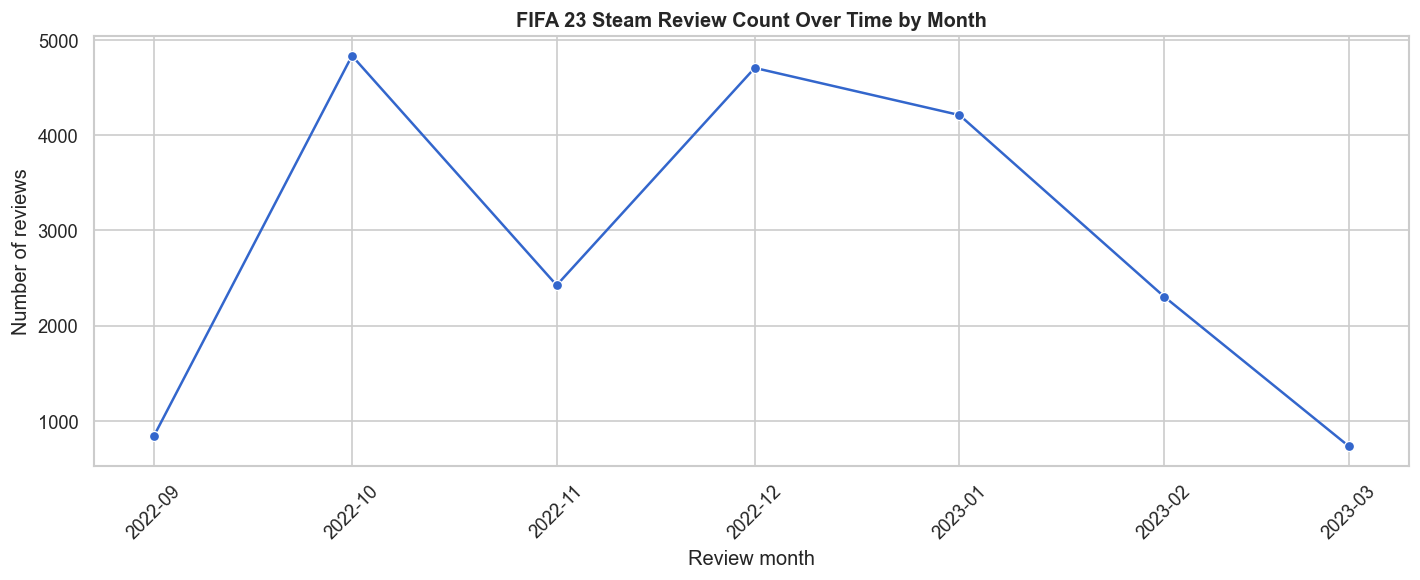

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\03_review_count_over_time_by_month.png


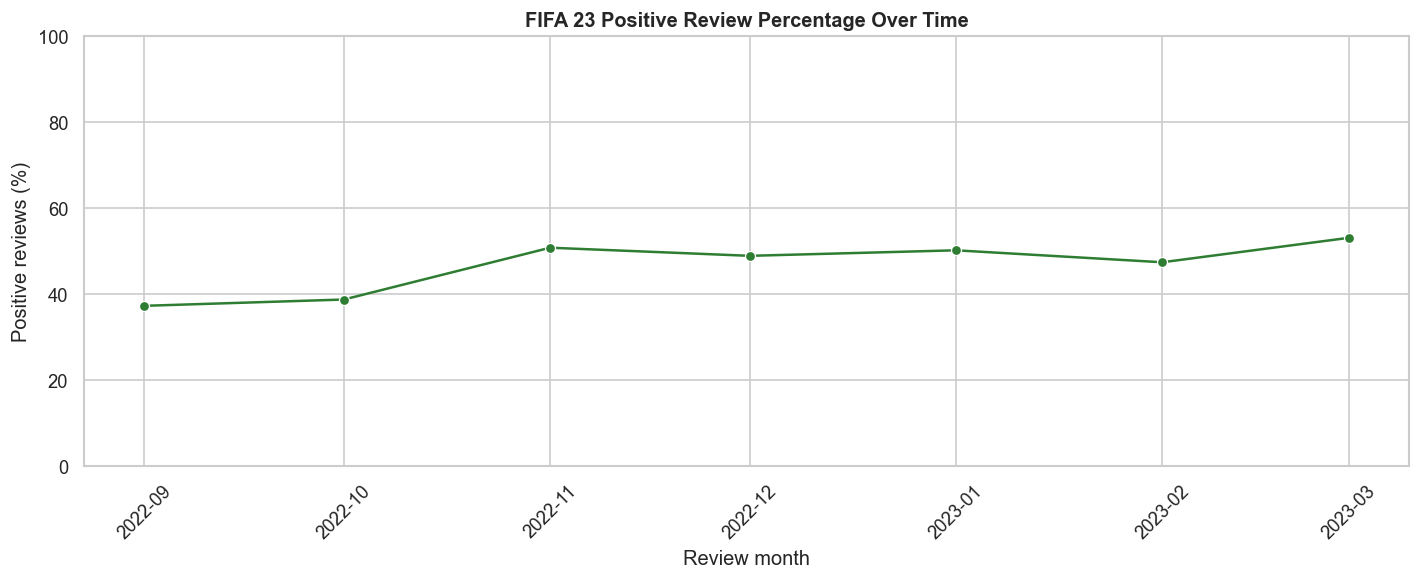

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\04_average_sentiment_over_time_by_month.png


In [7]:
# Create one monthly summary table reused by both time-series plots and H3.
monthly_sentiment = df_clean.dropna(subset=["created_month"]).groupby("created_month").agg(
    review_count=("raw_review", "size"),
    average_sentiment=("sentiment_binary", "mean"),
    positive_percentage=("sentiment_binary", lambda x: x.mean() * 100),
).reset_index()

# 3) Review volume trend: how many reviews were created each month.
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sentiment, x="created_month", y="review_count", marker="o", color="#3366CC")
plt.title("FIFA 23 Steam Review Count Over Time by Month"); plt.xlabel("Review month"); plt.ylabel("Number of reviews"); plt.xticks(rotation=45)
savefig("03_review_count_over_time_by_month.png")

# 4) Sentiment trend: percentage of reviews that are positive each month.
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sentiment, x="created_month", y="positive_percentage", marker="o", color="#2E7D32")
plt.title("FIFA 23 Positive Review Percentage Over Time"); plt.xlabel("Review month"); plt.ylabel("Positive reviews (%)"); plt.ylim(0, 100); plt.xticks(rotation=45)
savefig("04_average_sentiment_over_time_by_month.png")



### 5.3 Review Length Distribution

Inspect review length while capping the x-axis at the 99th percentile for readability.

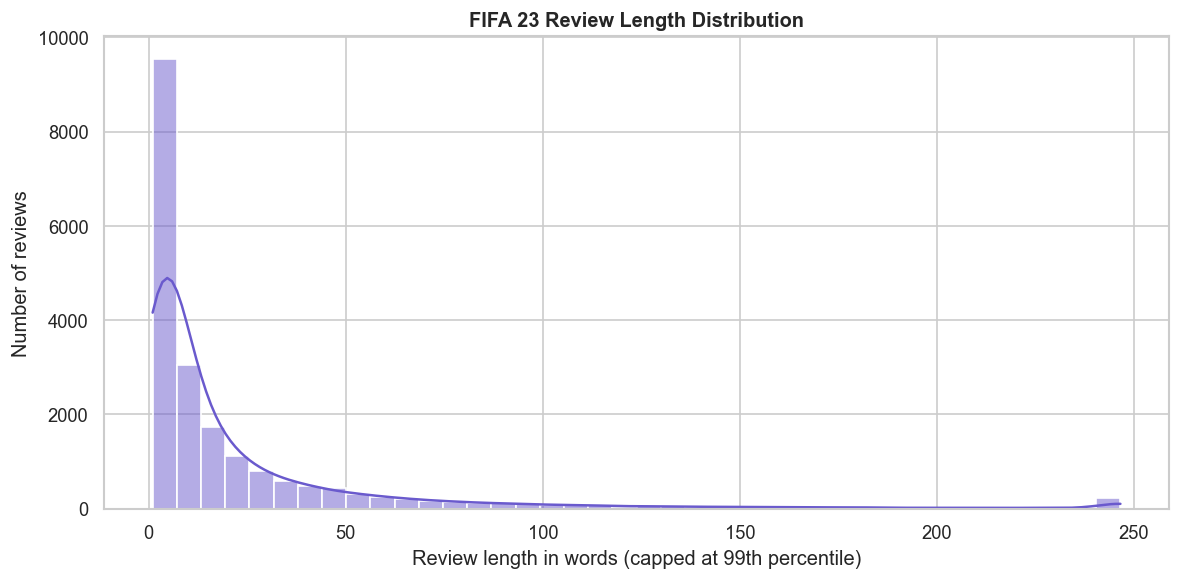

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\05_review_length_distribution.png


In [8]:
# 5) Review length distribution. The 99th percentile cap prevents a few very long reviews from hiding the main pattern.
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["review_length_words"].clip(upper=df_clean["review_length_words"].quantile(0.99)), bins=40, kde=True, color="#6A5ACD")
plt.title("FIFA 23 Review Length Distribution"); plt.xlabel("Review length in words (capped at 99th percentile)"); plt.ylabel("Number of reviews")
savefig("05_review_length_distribution.png")



### 5.4 Metadata Distributions by Sentiment

Compare recent playtime and owned games across positive and negative Steam recommendations.

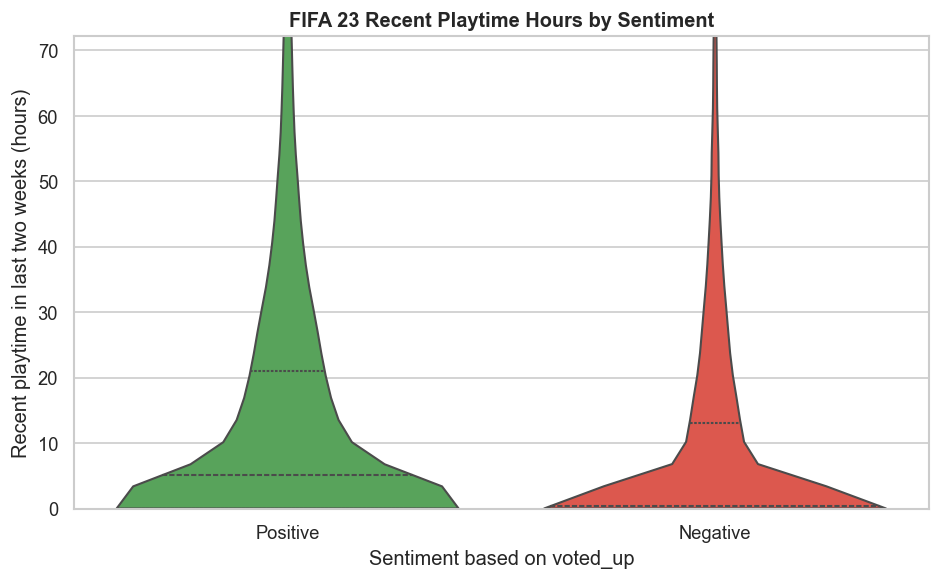

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\06_recent_playtime_hours_by_sentiment.png


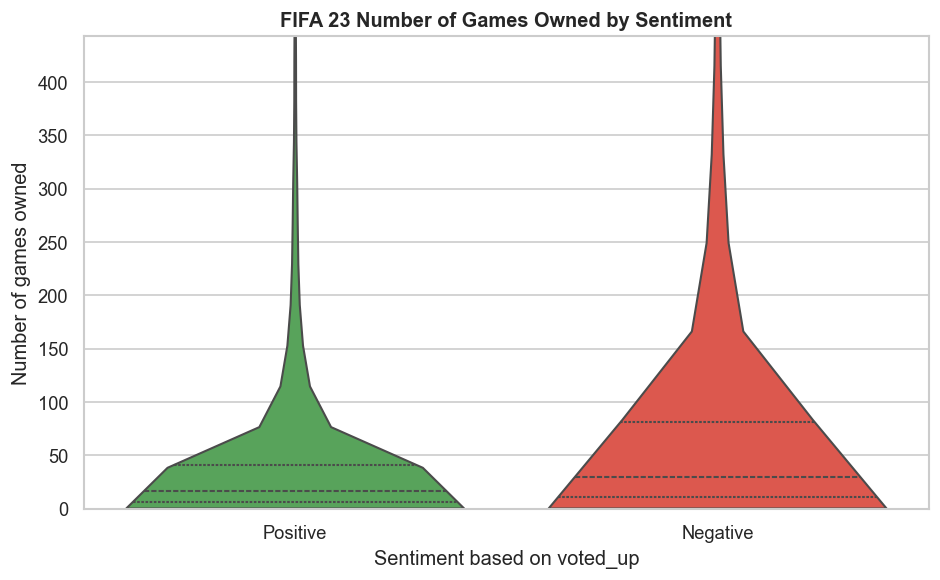

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\07_games_owned_by_sentiment.png


In [9]:
# 6) Compare recent playtime distributions for positive and negative reviewers.
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x="sentiment_label", y="author_playtime_last_two_weeks_hours", order=["Positive", "Negative"], cut=0, inner="quartile", palette=["#4CAF50", "#F44336"])
plt.ylim(0, df_clean["author_playtime_last_two_weeks_hours"].quantile(0.98)); plt.title("FIFA 23 Recent Playtime Hours by Sentiment"); plt.xlabel("Sentiment based on voted_up"); plt.ylabel("Recent playtime in last two weeks (hours)")
savefig("06_recent_playtime_hours_by_sentiment.png")

# 7) Compare number of owned games across sentiment groups.
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x="sentiment_label", y="author_num_games_owned", order=["Positive", "Negative"], cut=0, inner="quartile", palette=["#4CAF50", "#F44336"])
plt.ylim(0, df_clean["author_num_games_owned"].quantile(0.98)); plt.title("FIFA 23 Number of Games Owned by Sentiment"); plt.xlabel("Sentiment based on voted_up"); plt.ylabel("Number of games owned")
savefig("07_games_owned_by_sentiment.png")


### 5.5 Numeric Metadata Correlation

Use a heatmap to inspect metadata relationships with the binary sentiment label.

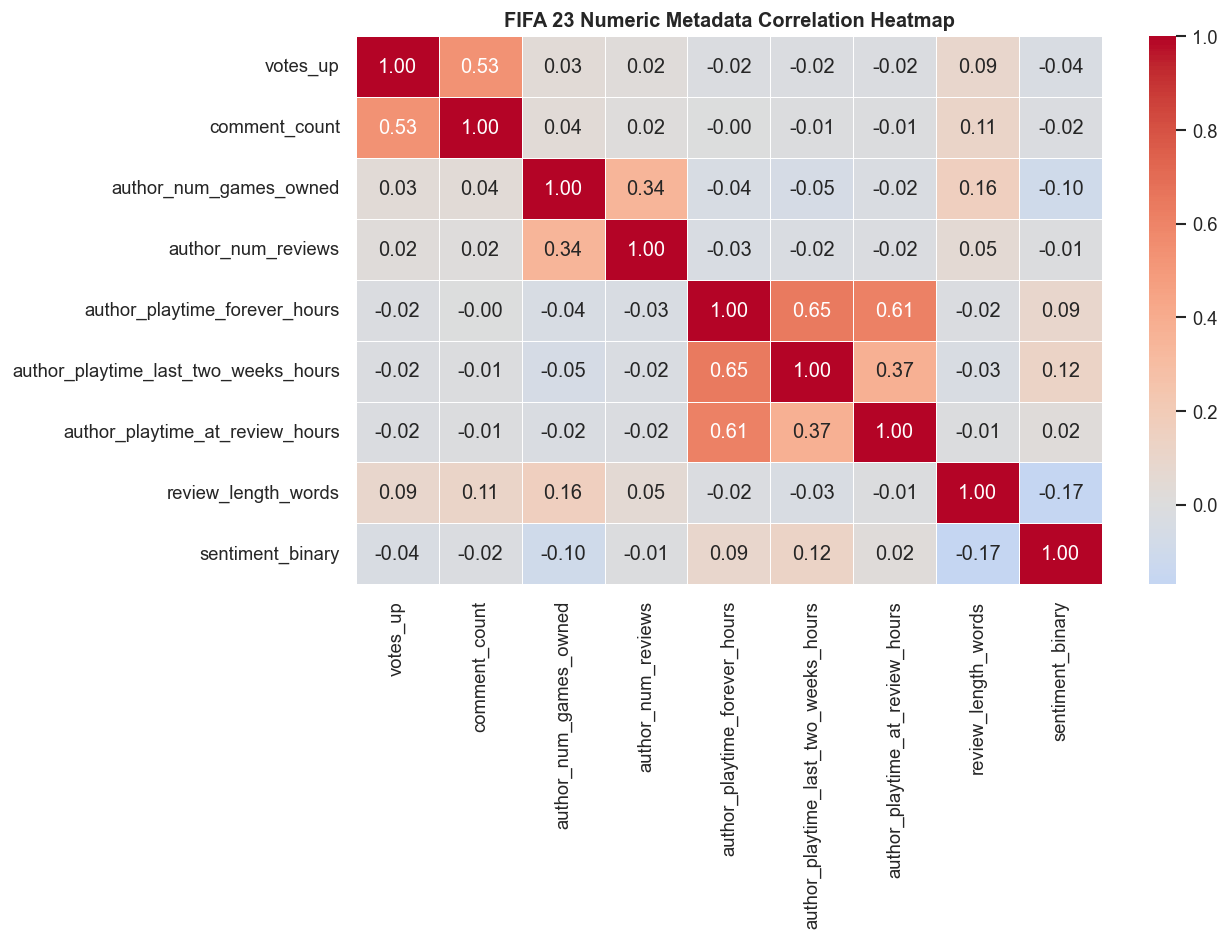

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\08_numeric_metadata_correlation_heatmap.png


In [10]:
# Generate text-focused EDA figures: correlation heatmap, frequent words, word clouds, and class-specific TF-IDF terms.
# Select numeric metadata fields plus sentiment so relationships can be inspected in one heatmap.
corr_cols = ["votes_up", "comment_count", "author_num_games_owned", "author_num_reviews", "author_playtime_forever_hours", "author_playtime_last_two_weeks_hours", "author_playtime_at_review_hours", "review_length_words", "sentiment_binary"]
plt.figure(figsize=(11, 8))
sns.heatmap(df_clean[corr_cols].apply(pd.to_numeric, errors="coerce").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("FIFA 23 Numeric Metadata Correlation Heatmap")
savefig("08_numeric_metadata_correlation_heatmap.png")



### 5.6 Frequent Words

Count the most common cleaned tokens across all reviews.

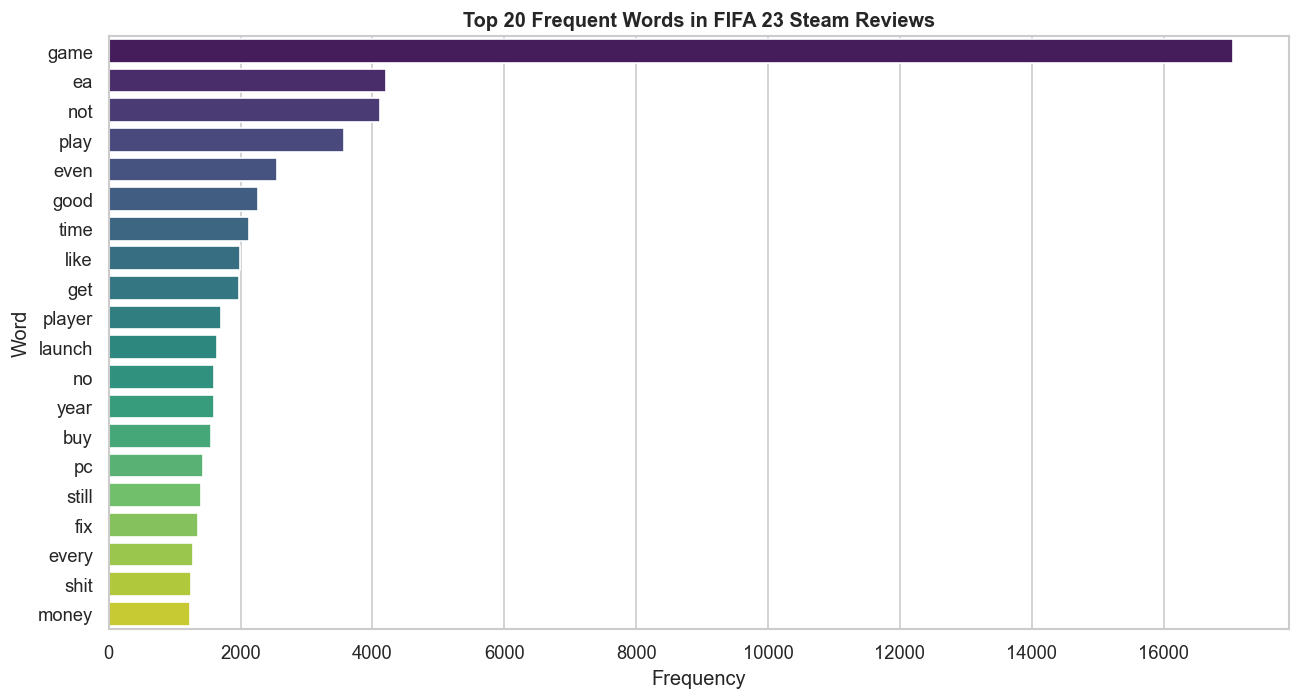

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\09_top_20_frequent_words_overall.png


,word,count
0,game,17047
1,ea,4199
2,not,4109
3,play,3566
4,even,2555
5,good,2262
6,time,2123
7,like,1985
8,get,1981
9,player,1710


In [11]:
# Flatten all cleaned reviews into tokens and count the most common words.
all_tokens = " ".join(df_clean["clean_review"]).split()
top_words_df = pd.DataFrame(Counter(all_tokens).most_common(20), columns=["word", "count"])
words_to_plot = top_words_df["word"].tolist()
counts_to_plot = top_words_df["count"].tolist()
plt.figure(figsize=(11, 6))
sns.barplot(data=top_words_df, x="count", y="word", palette="viridis")
plt.title("Top 20 Frequent Words in FIFA 23 Steam Reviews"); plt.xlabel("Frequency"); plt.ylabel("Word")
savefig("09_top_20_frequent_words_overall.png")
display(top_words_df)



### 5.7 Word Clouds

Generate separate word clouds for positive and negative reviews.

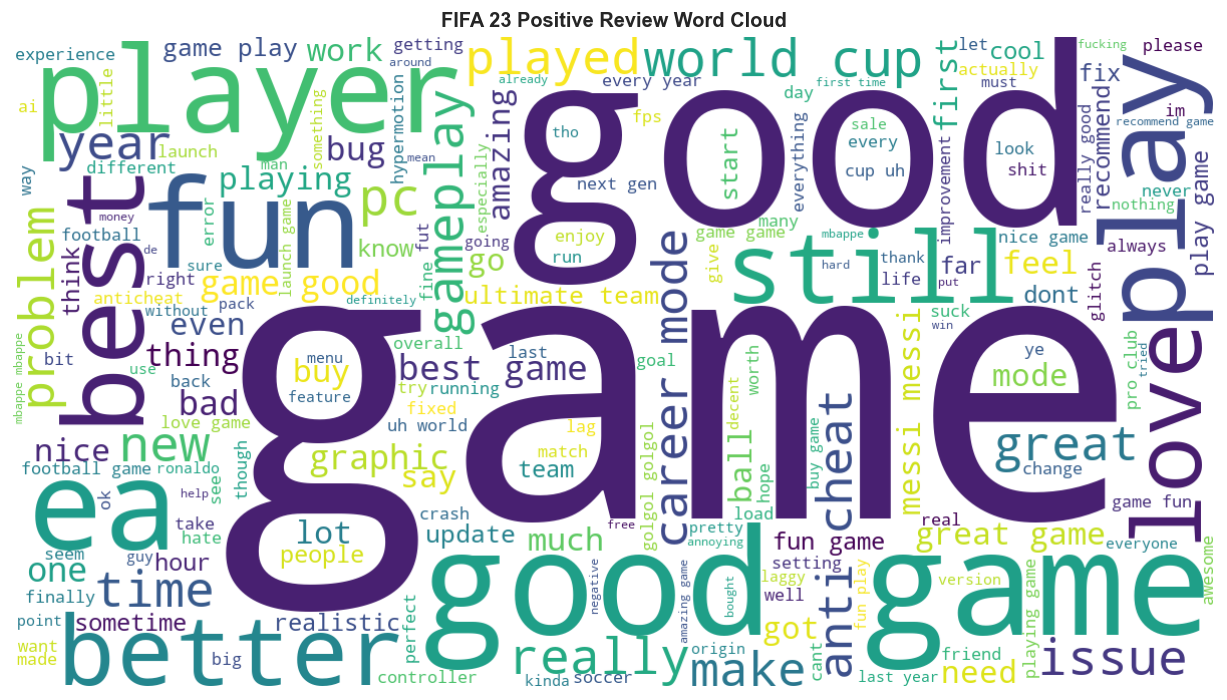

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\10_positive_word_cloud.png


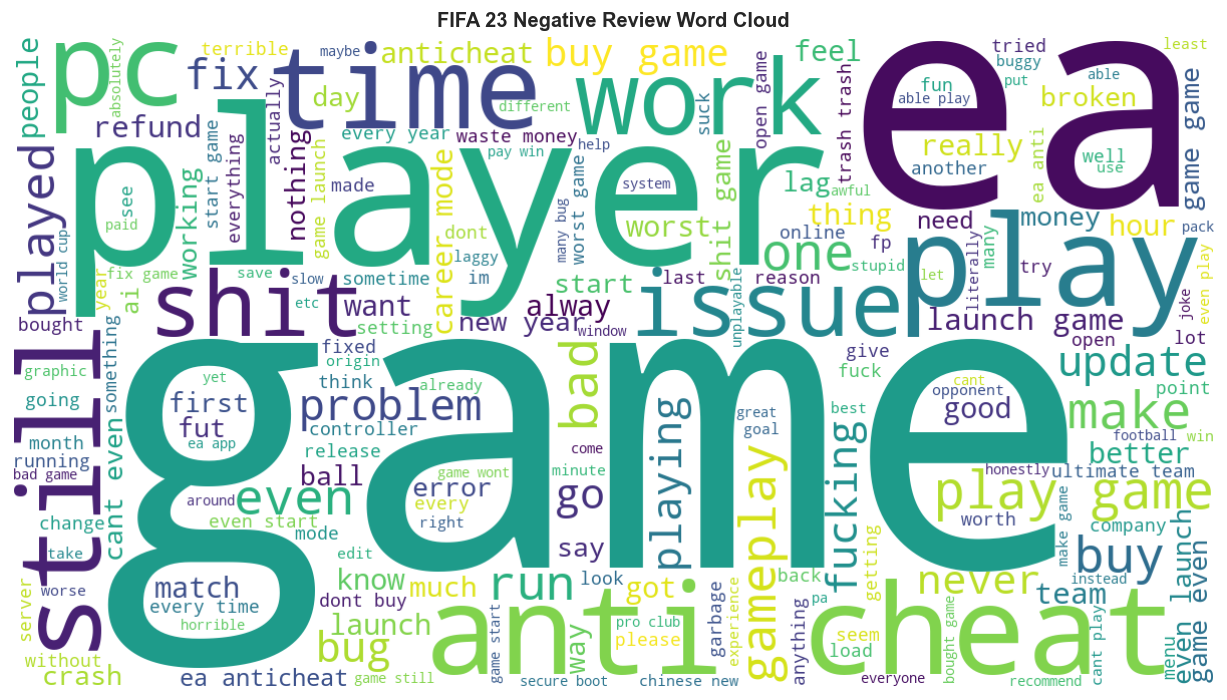

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\11_negative_word_cloud.png


In [12]:
# Reusable word-cloud helper keeps positive and negative word cloud code consistent.
def plot_wordcloud(text, title, filename):
    plt.figure(figsize=(11, 6))
    if str(text).strip():
        cloud = WordCloud(width=1200, height=650, background_color="white", colormap="viridis", random_state=RANDOM_STATE).generate(text)
        plt.imshow(cloud, interpolation="bilinear")
    else:
        plt.text(0.5, 0.5, "No words available", ha="center", va="center", fontsize=16)
    plt.axis("off"); plt.title(title); savefig(filename)

plot_wordcloud(" ".join(df_clean.loc[df_clean["sentiment_label"] == "Positive", "clean_review"]), "FIFA 23 Positive Review Word Cloud", "10_positive_word_cloud.png")
plot_wordcloud(" ".join(df_clean.loc[df_clean["sentiment_label"] == "Negative", "clean_review"]), "FIFA 23 Negative Review Word Cloud", "11_negative_word_cloud.png")



### 5.8 Class-Specific TF-IDF Terms

Compare the terms most associated with positive and negative reviews.

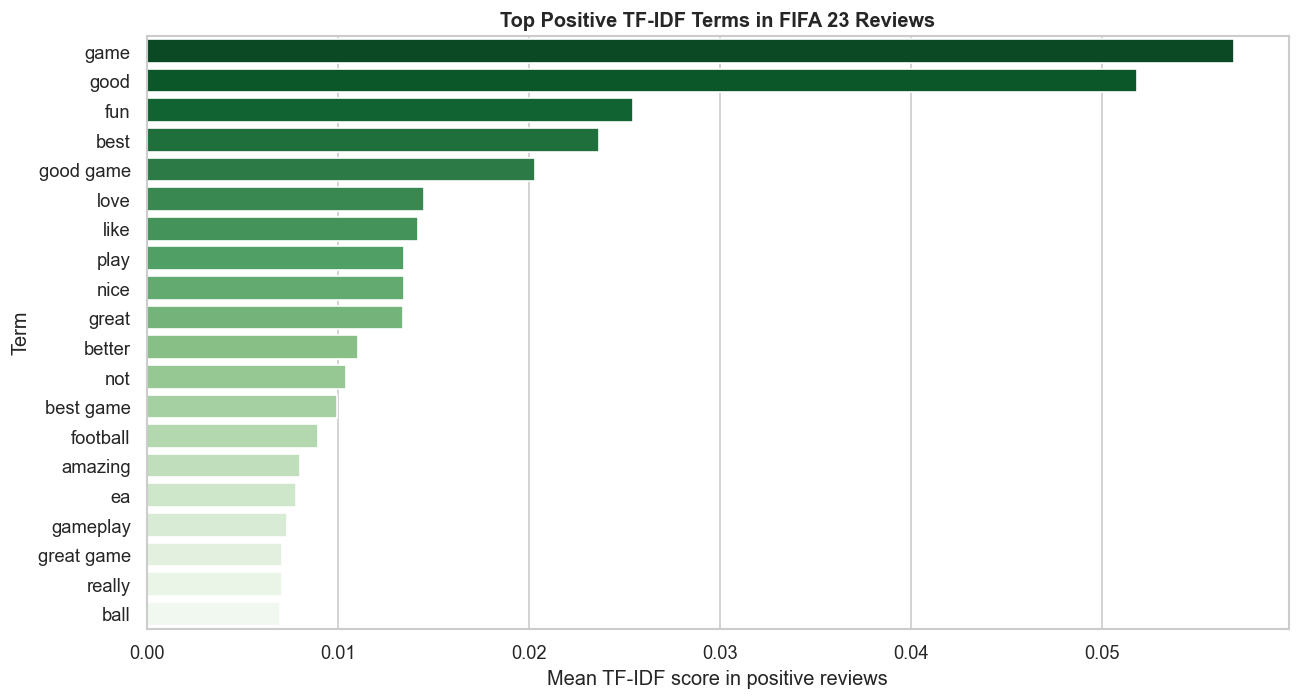

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\12_top_positive_tfidf_terms.png


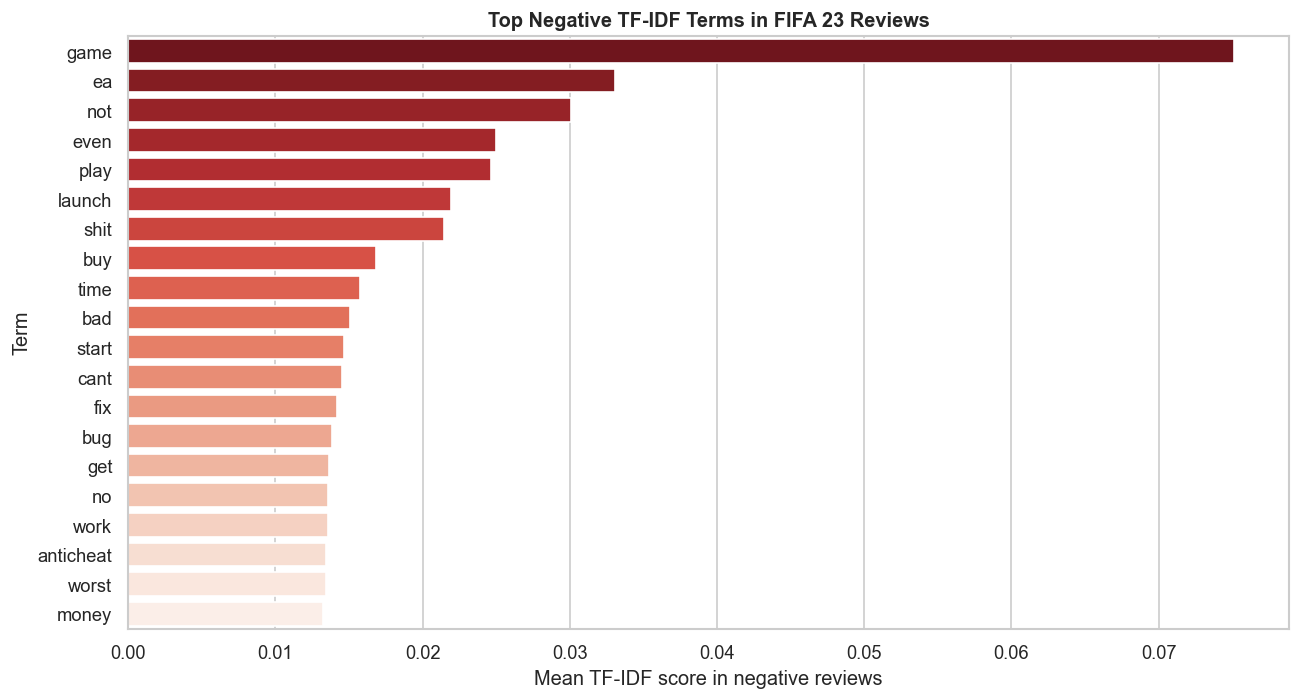

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\13_top_negative_tfidf_terms.png


,term,tfidf_score
0,game,0.056954
1,good,0.051829
2,fun,0.025467
3,best,0.023685
4,good game,0.020341
5,love,0.014523
6,like,0.014187
7,play,0.013487
8,nice,0.013451
9,great,0.013413


,term,tfidf_score
0,game,0.075089
1,ea,0.033084
2,not,0.030053
3,even,0.024968
4,play,0.024678
5,launch,0.021929
6,shit,0.021477
7,buy,0.016847
8,time,0.015771
9,bad,0.015080


In [13]:
# Fit an EDA-only TF-IDF vectorizer to compare terms that are prominent in each sentiment class.
eda_tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9, ngram_range=(1, 2))
eda_mat = eda_tfidf.fit_transform(df_clean["clean_review"])
features = np.array(eda_tfidf.get_feature_names_out())
# Average TF-IDF scores separately for positive and negative reviews.
pos_scores = np.asarray(eda_mat[df_clean["sentiment_binary"].values == 1].mean(axis=0)).ravel()
neg_scores = np.asarray(eda_mat[df_clean["sentiment_binary"].values == 0].mean(axis=0)).ravel()
top_positive_terms = pd.DataFrame({"term": features[np.argsort(pos_scores)[-20:][::-1]], "tfidf_score": np.sort(pos_scores)[-20:][::-1]})
top_negative_terms = pd.DataFrame({"term": features[np.argsort(neg_scores)[-20:][::-1]], "tfidf_score": np.sort(neg_scores)[-20:][::-1]})

plt.figure(figsize=(11, 6)); sns.barplot(data=top_positive_terms, x="tfidf_score", y="term", palette="Greens_r")
plt.title("Top Positive TF-IDF Terms in FIFA 23 Reviews"); plt.xlabel("Mean TF-IDF score in positive reviews"); plt.ylabel("Term")
savefig("12_top_positive_tfidf_terms.png")

plt.figure(figsize=(11, 6)); sns.barplot(data=top_negative_terms, x="tfidf_score", y="term", palette="Reds_r")
plt.title("Top Negative TF-IDF Terms in FIFA 23 Reviews"); plt.xlabel("Mean TF-IDF score in negative reviews"); plt.ylabel("Term")
savefig("13_top_negative_tfidf_terms.png")
display(top_positive_terms); display(top_negative_terms)


## 6. Hypothesis Testing

This section tests the report hypotheses using statistical methods that fit the data types.

H1 and H2 compare skewed numeric metadata between positive and negative reviews, so the Mann-Whitney U test is used instead of assuming normal distributions. H3 checks whether sentiment distribution changes across review months using a chi-square test.

H4 compares written sentiment from review text against the Steam `voted_up` recommendation label. The project remains a **binary supervised sentiment task** because the available ground-truth label has only two values: `True` means recommended/positive and `False` means not recommended/negative. The Steam dataset does not provide a reliable neutral label, so neutral cannot be used as a supervised class without manual annotation.

VADER can still be used descriptively as a 3-class lexicon method: Positive, Neutral, and Negative. However, for a direct confusion matrix or agreement score against `voted_up`, both labels must share the same class structure. Therefore, this notebook first reports VADER's 3-class distribution and then converts VADER to a binary label using the same rule used earlier in the project: compound score `>= 0` is Positive and compound score `< 0` is Negative.


### 6.1 H1 and H2: Behaviour Metadata Tests

Use Mann-Whitney U tests for skewed playtime and games-owned metadata.

In [14]:
# Run the four report hypothesis checks and store the results in a dataframe for export.
hypothesis_results = []
def add_hypothesis_result(hypothesis, test, statistic, p_value, interpretation):
    hypothesis_results.append({"Hypothesis": hypothesis, "Test": test, "Statistic": statistic, "p_value": p_value, "Interpretation": interpretation})

def mann_whitney(column, hypothesis):
    pos = df_clean.loc[df_clean["sentiment_label"] == "Positive", column].dropna()
    neg = df_clean.loc[df_clean["sentiment_label"] == "Negative", column].dropna()
    stat, p = mannwhitneyu(pos, neg, alternative="two-sided")
    interp = f"p={p:.4g}; Positive median={pos.median():.2f}, Negative median={neg.median():.2f}. " + ("Significant difference detected." if p < 0.05 else "No statistically significant difference detected.")
    add_hypothesis_result(hypothesis, "Mann-Whitney U test", stat, p, interp)
    print(hypothesis, "\n", interp, "\n")

mann_whitney("author_playtime_last_two_weeks_hours", "H1: Players with higher recent playtime are more likely to leave positive reviews")
mann_whitney("author_num_games_owned", "H2: Players who own more games are more likely to provide negative reviews")



H1: Players with higher recent playtime are more likely to leave positive reviews 
 p=5.921e-121; Positive median=5.07, Negative median=0.32. Significant difference detected. 

H2: Players who own more games are more likely to provide negative reviews 
 p=7.634e-187; Positive median=16.00, Negative median=30.00. Significant difference detected. 



### 6.2 H3: Monthly Sentiment Change

Use a chi-square test and line plot for month-by-sentiment changes.

H3: p=7.256e-43; sentiment distribution changes significantly over time.


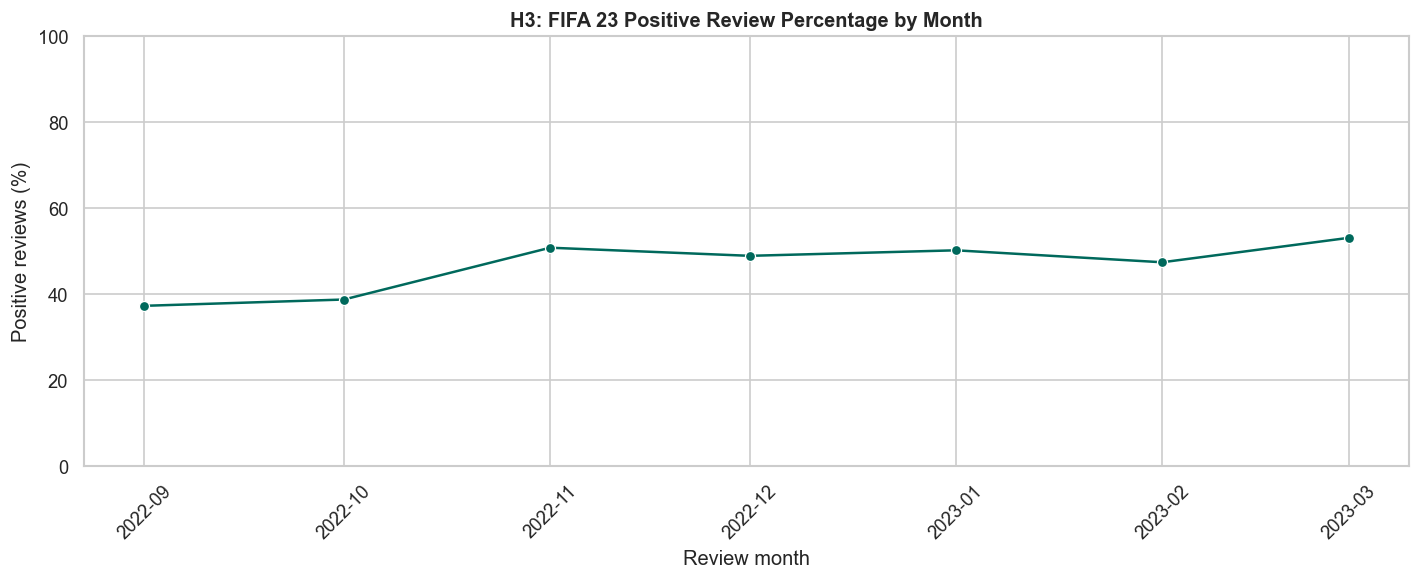

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\14_h3_positive_review_percentage_by_month.png


In [15]:
month_table = pd.crosstab(df_clean["created_month"], df_clean["sentiment_label"])
if month_table.shape[0] > 1 and month_table.shape[1] > 1:
    chi2_stat, chi2_p, _, _ = chi2_contingency(month_table)
    h3_interp = f"p={chi2_p:.4g}; " + ("sentiment distribution changes significantly over time." if chi2_p < 0.05 else "no significant month-by-sentiment association detected.")
else:
    chi2_stat, chi2_p, h3_interp = np.nan, np.nan, "Not enough monthly groups for chi-square testing."
add_hypothesis_result("H3: Sentiment changes over time", "Chi-square test of month vs sentiment", chi2_stat, chi2_p, h3_interp)
print("H3:", h3_interp)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sentiment, x="created_month", y="positive_percentage", marker="o", color="#00695C")
plt.title("H3: FIFA 23 Positive Review Percentage by Month"); plt.xlabel("Review month"); plt.ylabel("Positive reviews (%)"); plt.ylim(0, 100); plt.xticks(rotation=45)
savefig("14_h3_positive_review_percentage_by_month.png")



### 6.3 VADER 3-Class Distribution

Show VADER's descriptive Positive, Neutral, and Negative labels before binary conversion.

,vader_label,review_count,percentage
0,Positive,7167,35.745636
1,Neutral,6224,31.042394
2,Negative,6659,33.211970


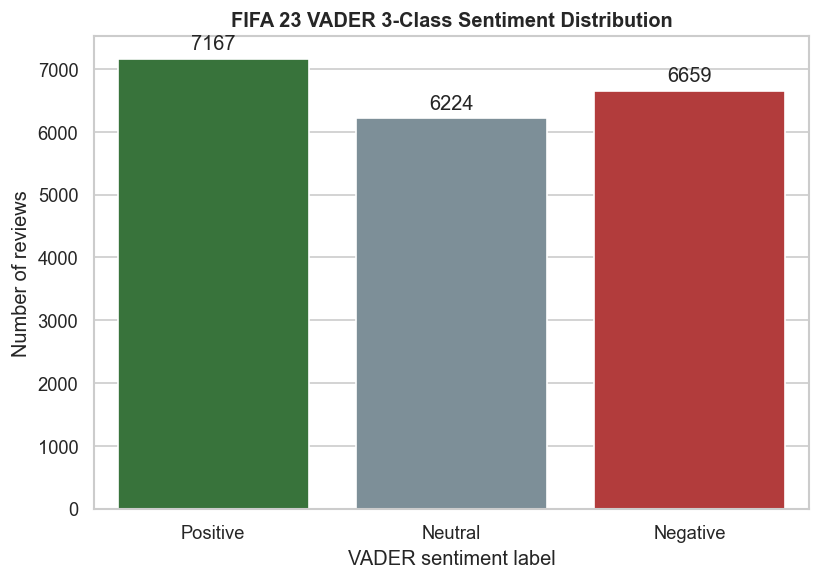

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\32_vader_3class_distribution.png


In [16]:
# H4: VADER supports 3-class lexicon sentiment, while Steam voted_up is binary.
# First, calculate the standard VADER 3-class labels for descriptive analysis.
sia = SentimentIntensityAnalyzer()
df_clean["vader_compound"] = df_clean["raw_review"].apply(lambda t: sia.polarity_scores(str(t))["compound"])
df_clean["vader_label_3class"] = np.select(
    [df_clean["vader_compound"] >= 0.05, df_clean["vader_compound"] <= -0.05],
    ["Positive", "Negative"],
    default="Neutral",
)
# Keep the earlier column name as an alias so downstream report code remains compatible.
df_clean["vader_label_detailed"] = df_clean["vader_label_3class"]

vader_3class_distribution_df = (
    df_clean["vader_label_3class"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"], fill_value=0)
    .rename_axis("vader_label")
    .reset_index(name="review_count")
)
vader_3class_distribution_df["percentage"] = (
    vader_3class_distribution_df["review_count"] / len(df_clean) * 100
)
display(vader_3class_distribution_df)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=vader_3class_distribution_df,
    x="vader_label",
    y="review_count",
    order=["Positive", "Neutral", "Negative"],
    palette=["#2E7D32", "#78909C", "#C62828"],
)
plt.title("FIFA 23 VADER 3-Class Sentiment Distribution")
plt.xlabel("VADER sentiment label")
plt.ylabel("Number of reviews")
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%d", padding=3)
savefig("32_vader_3class_distribution.png")



### 6.4 H4: Binary VADER Agreement with voted_up

Convert VADER to binary so it can be compared directly with Steam recommendation labels.

H4: VADER binary sentiment agrees with voted_up for 69.36% of cleaned reviews. VADER 3-class labels are reported descriptively, but binary conversion is required for direct comparison because Steam voted_up has no neutral ground-truth class.


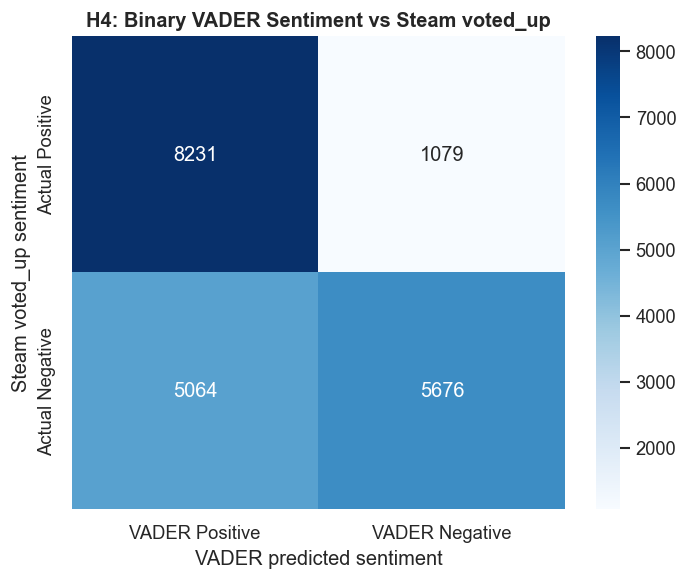

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\15_h4_vader_vs_voted_up_confusion_matrix.png


In [17]:
# For H4, VADER must be converted to binary before comparison with voted_up.
# The previous project rule is preserved: compound >= 0 is Positive; compound < 0 is Negative.
# This splits neutral-range VADER reviews by the sign of their compound score, because voted_up has no neutral class.
df_clean["vader_binary_label"] = np.where(df_clean["vader_compound"] >= 0, "Positive", "Negative")

vader_binary_distribution_df = (
    df_clean["vader_binary_label"]
    .value_counts()
    .reindex(["Positive", "Negative"], fill_value=0)
    .rename_axis("vader_binary_label")
    .reset_index(name="review_count")
)
vader_binary_distribution_df["percentage"] = (
    vader_binary_distribution_df["review_count"] / len(df_clean) * 100
)
display(vader_binary_distribution_df)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=vader_binary_distribution_df,
    x="vader_binary_label",
    y="review_count",
    hue="vader_binary_label",
    order=["Positive", "Negative"],
    palette=["#2E7D32", "#C62828"],
    legend=False,
)
ax.set_title("FIFA 23 Binary VADER Sentiment Distribution")
ax.set_xlabel("Binary VADER sentiment label")
ax.set_ylabel("Number of reviews")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
savefig("42_vader_binary_distribution.png")

agreement = (df_clean["vader_binary_label"] == df_clean["sentiment_label"]).mean()
h4_interp = (
    f"VADER binary sentiment agrees with voted_up for {agreement:.2%} of cleaned reviews. "
    "VADER 3-class labels are reported descriptively, but binary conversion is required for direct comparison "
    "because Steam voted_up has no neutral ground-truth class."
)
add_hypothesis_result("H4: Written sentiment agrees with Steam voted_up recommendation", "VADER vs voted_up agreement", agreement, np.nan, h4_interp)
print("H4:", h4_interp)

cm = confusion_matrix(df_clean["sentiment_label"], df_clean["vader_binary_label"], labels=["Positive", "Negative"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["VADER Positive", "VADER Negative"], yticklabels=["Actual Positive", "Actual Negative"])
plt.title("H4: Binary VADER Sentiment vs Steam voted_up")
plt.xlabel("VADER predicted sentiment")
plt.ylabel("Steam voted_up sentiment")
savefig("15_h4_vader_vs_voted_up_confusion_matrix.png")



### 6.5 Hypothesis Results Table

Collect the statistical outputs and show example VADER mismatch cases.

In [18]:
hypothesis_results_df = pd.DataFrame(hypothesis_results)
display(hypothesis_results_df)
display(df_clean.loc[df_clean["vader_binary_label"] != df_clean["sentiment_label"], ["raw_review", "sentiment_label", "vader_binary_label", "vader_compound"]].head(10))


,Hypothesis,Test,Statistic,p_value,Interpretation
0,H1: Players with higher recent playtime are more likely to leave positive reviews,Mann-Whitney U test,5.927902e+07,5.920753e-121,"p=5.921e-121; Positive median=5.07, Negative median=0.32. Significant difference detected."
1,H2: Players who own more games are more likely to provide negative reviews,Mann-Whitney U test,3.808099e+07,7.633997e-187,"p=7.634e-187; Positive median=16.00, Negative median=30.00. Significant difference detected."
2,H3: Sentiment changes over time,Chi-square test of month vs sentiment,2.113517e+02,7.256159e-43,p=7.256e-43; sentiment distribution changes significantly over time.
3,H4: Written sentiment agrees with Steam voted_up recommendation,VADER vs voted_up agreement,6.936160e-01,NaN,"VADER binary sentiment agrees with voted_up for 69.36% of cleaned reviews. VADER 3-class labels are reported descriptively, but binary conversion is required for direct compari..."


,raw_review,sentiment_label,vader_binary_label,vader_compound
2,i hate all the sweats who never touch grass,Positive,Negative,-0.5719
3,Fxxk u EAAntiCheat! Fxxk u EA!,Negative,Positive,0.0000
8,"If i want to play my career, i always have to start a new one to load the existing one.\nThis is no fun at all.....",Negative,Positive,0.5859
10,No progress saved. Resets everything at every restart.,Negative,Positive,0.5267
11,Game doesn't even opened on PC,Negative,Positive,0.0000
12,just dont play this game pls save yourself,Negative,Positive,0.3536
13,"mở game 5 6 lần mới vô được game, game rác, nhiều lỗi, game như cc",Negative,Positive,0.0000
34,"I would like to tell a short story about my experience with this awesome swagalicious game.\nAt first, the bugs and load speeds were so terrible that i thought I'd never play t...",Negative,Positive,0.6398
44,deez nuts,Positive,Negative,-0.3182
47,its the same fifa from 97,Negative,Positive,0.0000


## 7. Feature Engineering

This section converts cleaned review text into TF-IDF features for supervised machine learning. TF-IDF gives higher weight to terms that are important in a review but not too common across all reviews.

The split is stratified 80/20 so the train and test sets keep a similar positive/negative class distribution. The vectorizer uses unigrams and bigrams to capture both single words and short phrases.


In [19]:
# Convert cleaned text into TF-IDF features and create a stratified 80/20 train-test split.
X = df_clean["clean_review"]
y = df_clean["sentiment_binary"]
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, max_df=0.9)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
display(y_train.map({1: "Positive", 0: "Negative"}).value_counts(normalize=True).to_frame("training_share"))


Training TF-IDF shape: (16040, 10000)
Testing TF-IDF shape: (4010, 10000)


,training_share
sentiment_binary,
Negative,0.535661
Positive,0.464339


## 8. Traditional Machine Learning Models

This section trains supervised models that learn from TF-IDF review features and the `voted_up` sentiment label.

Models include Multinomial Naive Bayes, Logistic Regression, Linear SVM, and Random Forest. Each model is evaluated with accuracy, precision, recall, F1-score, a classification report, and a confusion matrix.


### 8.1 Train and Evaluate Traditional Models

Fit the TF-IDF classifiers and save their predictions and confusion matrices.


Training Multinomial Naive Bayes...
              precision    recall  f1-score   support

    Negative       0.74      0.91      0.82      2148
    Positive       0.86      0.62      0.72      1862

    accuracy                           0.78      4010
   macro avg       0.80      0.77      0.77      4010
weighted avg       0.80      0.78      0.77      4010



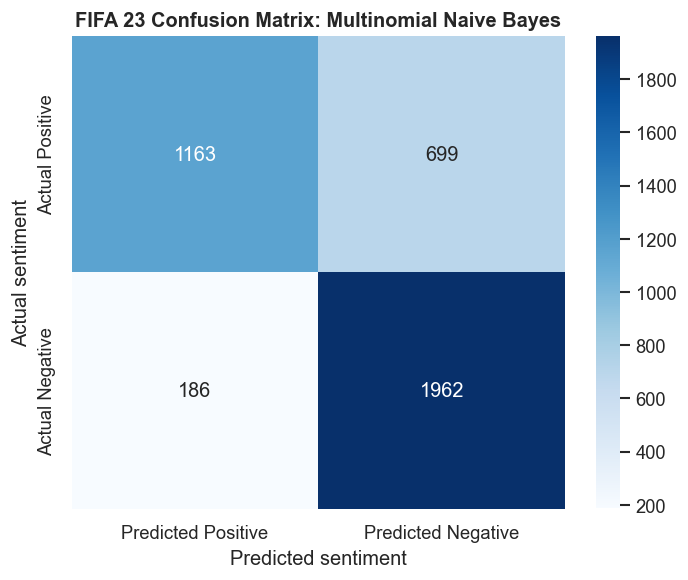

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\16_confusion_matrix_multinomial_naive_bayes.png

Training Logistic Regression...
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      2148
    Positive       0.84      0.85      0.85      1862

    accuracy                           0.86      4010
   macro avg       0.86      0.86      0.86      4010
weighted avg       0.86      0.86      0.86      4010



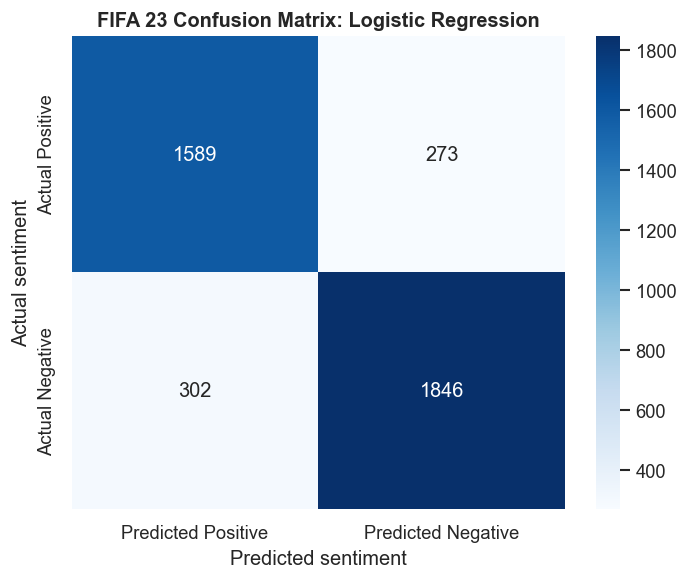

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\16_confusion_matrix_logistic_regression.png

Training Linear SVM...


              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      2148
    Positive       0.82      0.84      0.83      1862

    accuracy                           0.84      4010
   macro avg       0.84      0.84      0.84      4010
weighted avg       0.84      0.84      0.84      4010



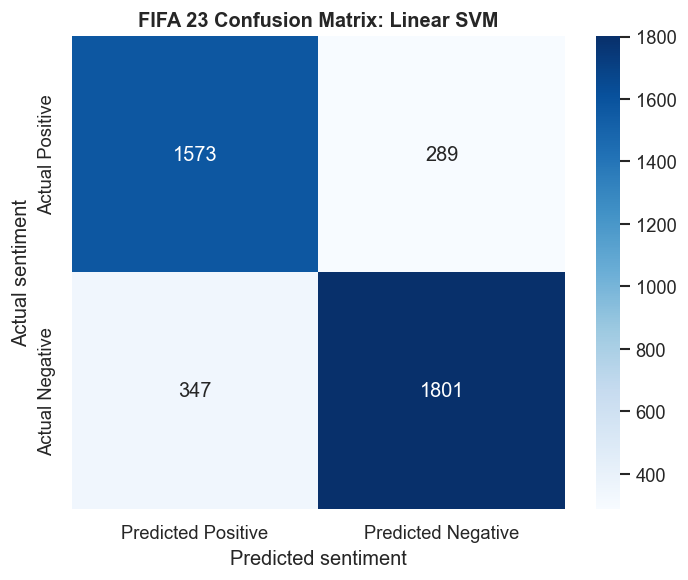

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\16_confusion_matrix_linear_svm.png

Training Random Forest...


              precision    recall  f1-score   support

    Negative       0.85      0.80      0.82      2148
    Positive       0.78      0.84      0.81      1862

    accuracy                           0.82      4010
   macro avg       0.82      0.82      0.82      4010
weighted avg       0.82      0.82      0.82      4010



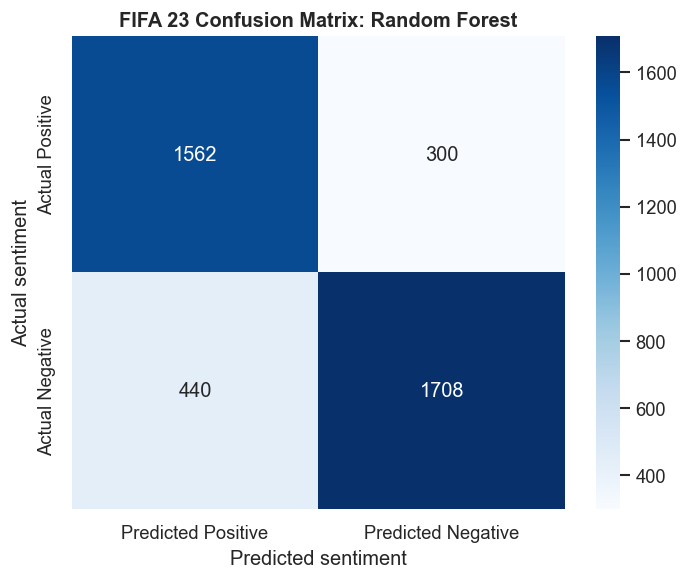

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\16_confusion_matrix_random_forest.png


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.856608,0.840296,0.853383,0.846789
1,Linear SVM,0.841397,0.819271,0.844791,0.831835
2,Random Forest,0.815461,0.780220,0.838883,0.808489
3,Multinomial Naive Bayes,0.779302,0.862120,0.624597,0.724385


In [20]:
# Train and evaluate the traditional supervised ML models using the same TF-IDF features and test set.
# Define models in one dictionary so the same training/evaluation loop can be reused.
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=1),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=60, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced_subsample"),
}
trained_models, model_predictions, rows = {}, {}, []
# Train each model, predict on the same test set, and store comparable metrics.
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    trained_models[name], model_predictions[name] = model, pred
    # Positive class is sentiment_binary=1, so precision/recall/F1 describe positive-review detection.
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred, zero_division=0), "Recall": recall_score(y_test, pred, zero_division=0), "F1-score": f1_score(y_test, pred, zero_division=0)})
    print(classification_report(y_test, pred, target_names=["Negative", "Positive"], zero_division=0))
    cm = confusion_matrix(y_test, pred, labels=[1, 0])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Positive", "Predicted Negative"], yticklabels=["Actual Positive", "Actual Negative"])
    plt.title(f"FIFA 23 Confusion Matrix: {name}"); plt.xlabel("Predicted sentiment"); plt.ylabel("Actual sentiment")
    savefig(f"16_confusion_matrix_{name.lower().replace(' ', '_').replace('-', '_')}.png")

model_results_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(model_results_df)



### 8.2 Traditional Model Comparison

Plot accuracy, precision, recall, and F1-score for the traditional classifiers.

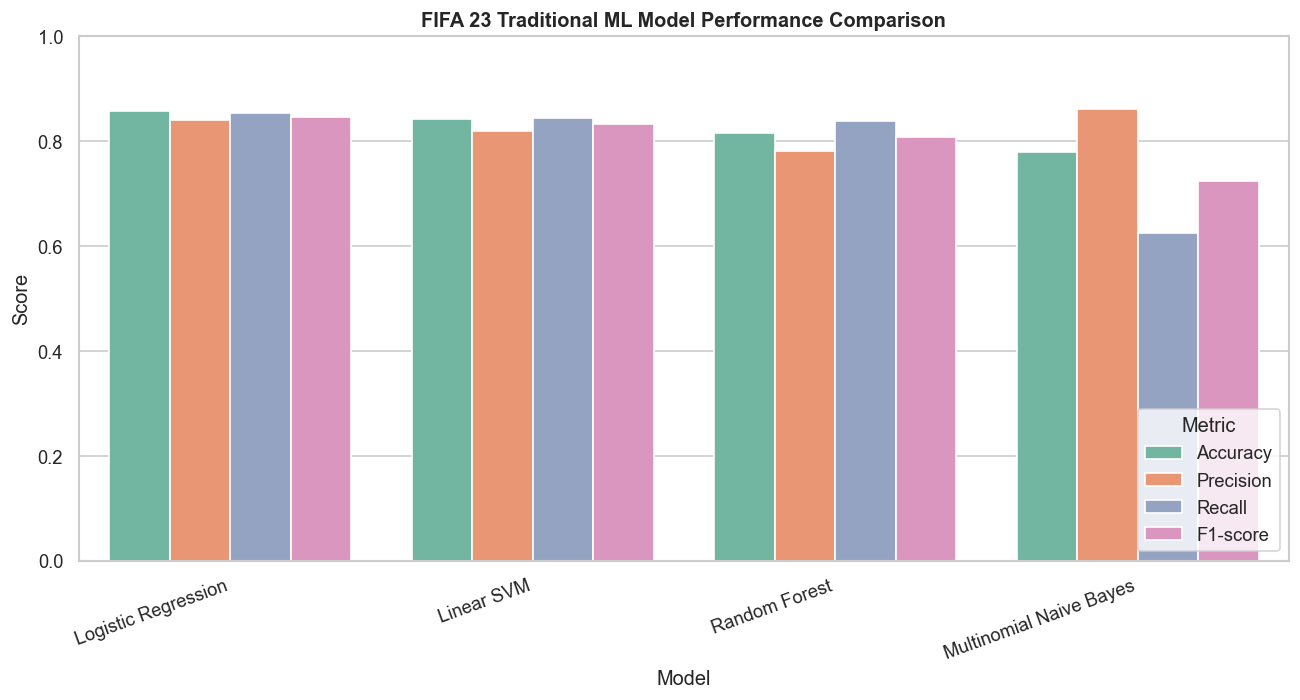

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\17_traditional_ml_model_performance_comparison.png


In [21]:
# Convert the wide metrics table into long format for a grouped bar chart.
long_results = model_results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"], var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=long_results, x="Model", y="Score", hue="Metric")
plt.title("FIFA 23 Traditional ML Model Performance Comparison"); plt.xlabel("Model"); plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=20, ha="right"); plt.legend(title="Metric", loc="lower right")
savefig("17_traditional_ml_model_performance_comparison.png")



### 8.3 Cross-Validation

Use five-fold stratified cross-validation for a stability check on selected models.

In [22]:
# Cross-validation estimates whether model performance is stable across different folds.
# n_jobs=1 is used for portability in restricted Windows/Colab-style environments.
cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in {k: models[k] for k in ["Multinomial Naive Bayes", "Logistic Regression", "Linear SVM"]}.items():
    pipe = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, max_df=0.9)), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring="f1", n_jobs=1)
    cv_results.append({"Model": name, "Mean_CV_F1": scores.mean(), "Std_CV_F1": scores.std()})
    print(f"{name}: mean CV F1={scores.mean():.4f}, std={scores.std():.4f}")
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)


Multinomial Naive Bayes: mean CV F1=0.7087, std=0.0105


Logistic Regression: mean CV F1=0.8402, std=0.0062


Linear SVM: mean CV F1=0.8356, std=0.0046


,Model,Mean_CV_F1,Std_CV_F1
0,Multinomial Naive Bayes,0.708666,0.010472
1,Logistic Regression,0.840204,0.006191
2,Linear SVM,0.835627,0.004608


## 9. Error Analysis

This section inspects cases where the best traditional model disagrees with the actual `voted_up` label. False positives are negative reviews predicted as positive, while false negatives are positive reviews predicted as negative.

These examples help explain model limitations such as sarcasm, short reviews, slang, mixed opinions, and football or gaming-specific vocabulary.


In [23]:
# Inspect false positives and false negatives from the best traditional model.
best_traditional_model_name = model_results_df.iloc[0]["Model"]
best_pred = model_predictions[best_traditional_model_name]
print(f"Best traditional model by F1-score: {best_traditional_model_name}")

test_rows = df_clean.loc[X_test_text.index].copy()
test_rows["actual_sentiment"] = y_test.map({1: "Positive", 0: "Negative"}).values
test_rows["predicted_sentiment"] = pd.Series(best_pred, index=y_test.index).map({1: "Positive", 0: "Negative"}).values

fp = test_rows[(test_rows["actual_sentiment"] == "Negative") & (test_rows["predicted_sentiment"] == "Positive")]
fn = test_rows[(test_rows["actual_sentiment"] == "Positive") & (test_rows["predicted_sentiment"] == "Negative")]
error_analysis_df = pd.concat([
    fp[["raw_review", "actual_sentiment", "predicted_sentiment", "review_length_words", "author_playtime_forever_hours"]].head(10).assign(error_type="False Positive"),
    fn[["raw_review", "actual_sentiment", "predicted_sentiment", "review_length_words", "author_playtime_forever_hours"]].head(10).assign(error_type="False Negative"),
], ignore_index=True).rename(columns={"raw_review": "review", "author_playtime_forever_hours": "playtime_hours"})
display(error_analysis_df)


Best traditional model by F1-score: Logistic Regression


,review,actual_sentiment,predicted_sentiment,review_length_words,playtime_hours,error_type
0,I have more respect towards EDP than any EA workers,Negative,Positive,10,39.983333,False Positive
1,so 5araaaaaa,Negative,Positive,2,185.483333,False Positive
2,this game is so riged,Negative,Positive,5,171.483333,False Positive
3,Not that good of a game freezez everytime in corners... Im on a 3060 ti so it shouldnt,Negative,Positive,18,1.716667,False Positive
4,"Ctrl + C, Ctrl + V, Repeat",Negative,Positive,7,196.366667,False Positive
5,Okay game\nHowever very frustrating what lagging can cost ALL THE TIME!!!,Negative,Positive,12,64.466667,False Positive
6,NUNEZ,Negative,Positive,1,100.216667,False Positive
7,Great launching sim,Negative,Positive,3,41.250000,False Positive
8,Same ol' glitchy game,Negative,Positive,4,374.533333,False Positive
9,sranje žešće,Negative,Positive,2,1.450000,False Positive


Common error causes include sarcasm, short reviews, slang, mixed opinions, and football/gaming-specific terms whose sentiment depends on player context.


## 10. Deep Learning and Transformer Models

This section has two related parts. First, the notebook evaluates a pretrained DistilBERT SST-2 sentiment pipeline as a practical transformer benchmark. This is useful for comparison, but it is not trained on the FIFA 23 dataset.

Second, the notebook trains a true deep learning model, a Bidirectional LSTM (BiLSTM), directly on the cleaned FIFA 23 Steam reviews using the binary `voted_up` label. The BiLSTM counts as a trained deep learning model because it learns an Embedding layer and recurrent neural network weights from the assignment dataset itself.


### 10.1 Transformer Setup

Initialize empty result tables and choose a Colab-friendly sample size.

In [24]:
# Run a practical transformer comparison on a stratified sample so the section remains Colab-friendly.
# Limit the sample size so the transformer section is useful but still realistic on free Colab/CPU sessions.
TRANSFORMER_SAMPLE_SIZE = min(2000, len(df_clean))
transformer_results_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
transformer_predictions_df = pd.DataFrame()
transformer_error_examples_df = pd.DataFrame()
transformer_confidence_summary_df = pd.DataFrame()



### 10.2 DistilBERT Benchmark

Run the pretrained DistilBERT SST-2 sentiment pipeline and evaluate it against `voted_up`.

In [25]:
# Import the transformer tools, create a stratified sample, and run the pretrained pipeline.
transformer_available = False
transformer_outputs = []
transformer_sample = pd.DataFrame()

try:
    import torch
    from transformers import pipeline

    if TRANSFORMER_SAMPLE_SIZE < len(df_clean):
        _, transformer_sample = train_test_split(
            df_clean,
            test_size=TRANSFORMER_SAMPLE_SIZE,
            stratify=df_clean["sentiment_binary"],
            random_state=RANDOM_STATE,
        )
    else:
        transformer_sample = df_clean.copy()

    device = 0 if torch.cuda.is_available() else -1
    print(f"Running DistilBERT sentiment pipeline on {len(transformer_sample):,} reviews with device={device}")
    sentiment_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

    transformer_outputs = sentiment_pipe(
        transformer_sample["raw_review"].astype(str).str.slice(0, 2000).tolist(),
        batch_size=32,
        truncation=True,
        max_length=512,
    )
    transformer_available = True
except Exception as exc:
    print("Transformer pipeline could not be completed in this runtime.")
    print("The setup cell includes install commands. Rerun this section with internet/model access if needed.")
    print(f"Error: {exc}")


Running DistilBERT sentiment pipeline on 2,000 reviews with device=-1


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

#### 10.2.1 Transformer Prediction Metrics

Map the pretrained labels to binary sentiment and evaluate them against `voted_up`.

In [26]:
# Evaluate transformer predictions against the same voted_up label used by the supervised ML models.
if transformer_available:
    transformer_sample = transformer_sample.copy()
    transformer_sample["transformer_raw_label"] = [item["label"] for item in transformer_outputs]
    transformer_sample["transformer_score"] = [item["score"] for item in transformer_outputs]
    transformer_sample["transformer_prediction"] = transformer_sample["transformer_raw_label"].str.upper().map({"POSITIVE": 1, "NEGATIVE": 0})
    transformer_sample = transformer_sample.dropna(subset=["transformer_prediction"]).copy()
    transformer_sample["transformer_prediction"] = transformer_sample["transformer_prediction"].astype(int)
    transformer_sample["transformer_sentiment"] = transformer_sample["transformer_prediction"].map({1: "Positive", 0: "Negative"})
    transformer_sample["transformer_matches_voted_up"] = transformer_sample["transformer_prediction"] == transformer_sample["sentiment_binary"]
    transformer_sample["confidence_band"] = pd.cut(
        transformer_sample["transformer_score"],
        bins=[0, 0.70, 0.85, 1.0],
        labels=["Low/Medium", "High", "Very High"],
        include_lowest=True,
    )

    t_y = transformer_sample["sentiment_binary"]
    t_pred = transformer_sample["transformer_prediction"]
    transformer_results_df = pd.DataFrame([{
        "Model": "Transformer DistilBERT SST-2",
        "Accuracy": accuracy_score(t_y, t_pred),
        "Precision": precision_score(t_y, t_pred, zero_division=0),
        "Recall": recall_score(t_y, t_pred, zero_division=0),
        "F1-score": f1_score(t_y, t_pred, zero_division=0),
    }])
    print(classification_report(t_y, t_pred, target_names=["Negative", "Positive"], zero_division=0))
else:
    print("Transformer metrics skipped because the pipeline was unavailable.")


              precision    recall  f1-score   support

    Negative       0.72      0.88      0.80      1071
    Positive       0.82      0.61      0.70       929

    accuracy                           0.76      2000
   macro avg       0.77      0.75      0.75      2000
weighted avg       0.77      0.76      0.75      2000



#### 10.2.2 Transformer Visuals and Error Examples

Save the transformer confusion matrix, confidence summary, and high-confidence mismatch examples.

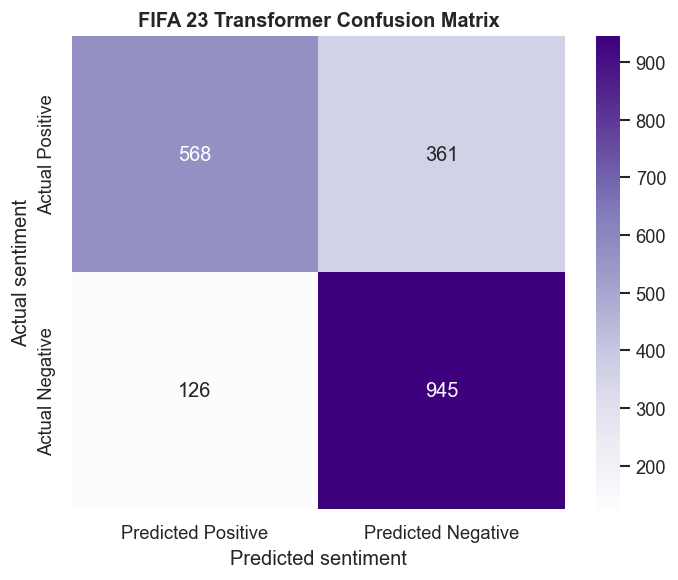

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\18_transformer_confusion_matrix.png


,confidence_band,transformer_matches_voted_up,review_count
0,Low/Medium,False,44
1,Low/Medium,True,32
2,High,False,38
3,High,True,37
4,Very High,False,405
5,Very High,True,1444


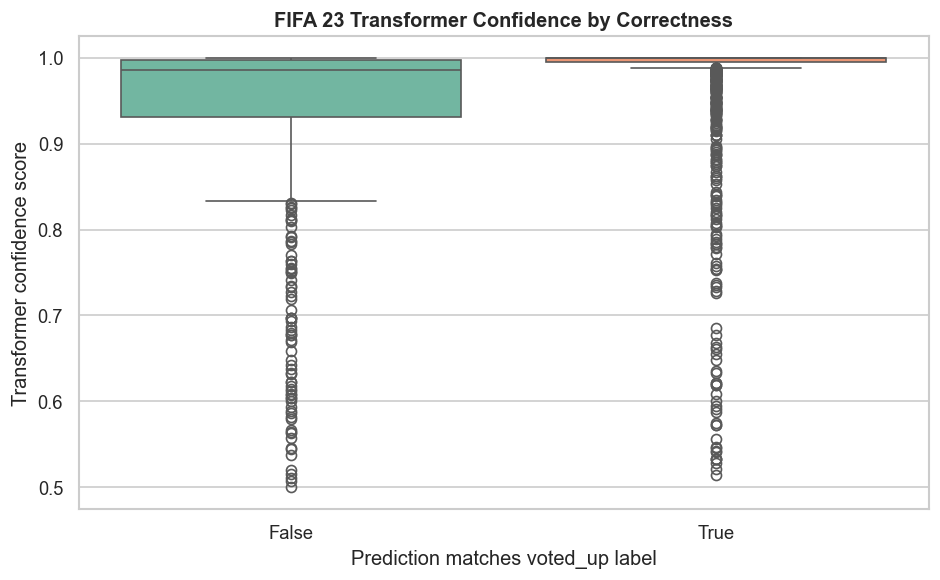

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\24_transformer_confidence_by_correctness.png


,review,sentiment_label,transformer_sentiment,transformer_score,review_length_words
12504,"Decryption game is fun, love.",Negative,Positive,0.999887,5
3646,i love it very,Negative,Positive,0.999882,4
6920,"Happy Chinese New Year, thieves of Korea.",Negative,Positive,0.999863,7
14286,wont launch. \nso fun :D,Negative,Positive,0.999857,5
5791,Happy Korean Lunar New Year,Negative,Positive,0.999854,5
15080,game wont launch,Negative,Positive,0.999847,3
21553,if want to waste time and money.\nAfter playing this game I lost my job.,Positive,Negative,0.999815,15
1244,The pack balance is so bad,Positive,Negative,0.999807,6
649,"good job EA, f*** you",Negative,Positive,0.999807,5
21628,It wont open,Negative,Positive,0.999802,3


In [27]:
if transformer_available and not transformer_results_df.empty:
    cm = confusion_matrix(t_y, t_pred, labels=[1, 0])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=["Predicted Positive", "Predicted Negative"], yticklabels=["Actual Positive", "Actual Negative"])
    plt.title("FIFA 23 Transformer Confusion Matrix")
    plt.xlabel("Predicted sentiment")
    plt.ylabel("Actual sentiment")
    savefig("18_transformer_confusion_matrix.png")

    transformer_confidence_summary_df = (
        transformer_sample.groupby(["confidence_band", "transformer_matches_voted_up"], observed=False)
        .size()
        .reset_index(name="review_count")
    )
    display(transformer_confidence_summary_df)

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=transformer_sample, x="transformer_matches_voted_up", y="transformer_score", palette="Set2")
    plt.title("FIFA 23 Transformer Confidence by Correctness")
    plt.xlabel("Prediction matches voted_up label")
    plt.ylabel("Transformer confidence score")
    savefig("24_transformer_confidence_by_correctness.png")

    transformer_error_examples_df = (
        transformer_sample.loc[
            ~transformer_sample["transformer_matches_voted_up"],
            ["raw_review", "sentiment_label", "transformer_sentiment", "transformer_score", "review_length_words"],
        ]
        .sort_values("transformer_score", ascending=False)
        .head(15)
        .rename(columns={"raw_review": "review"})
    )
    display(transformer_error_examples_df)

    transformer_predictions_df = transformer_sample[[
        "raw_review",
        "sentiment_label",
        "transformer_raw_label",
        "transformer_score",
        "transformer_prediction",
        "transformer_sentiment",
        "transformer_matches_voted_up",
        "confidence_band",
    ]].copy()


### 10.3 Transformer vs Traditional ML Comparison

Add the transformer benchmark to the model comparison table.

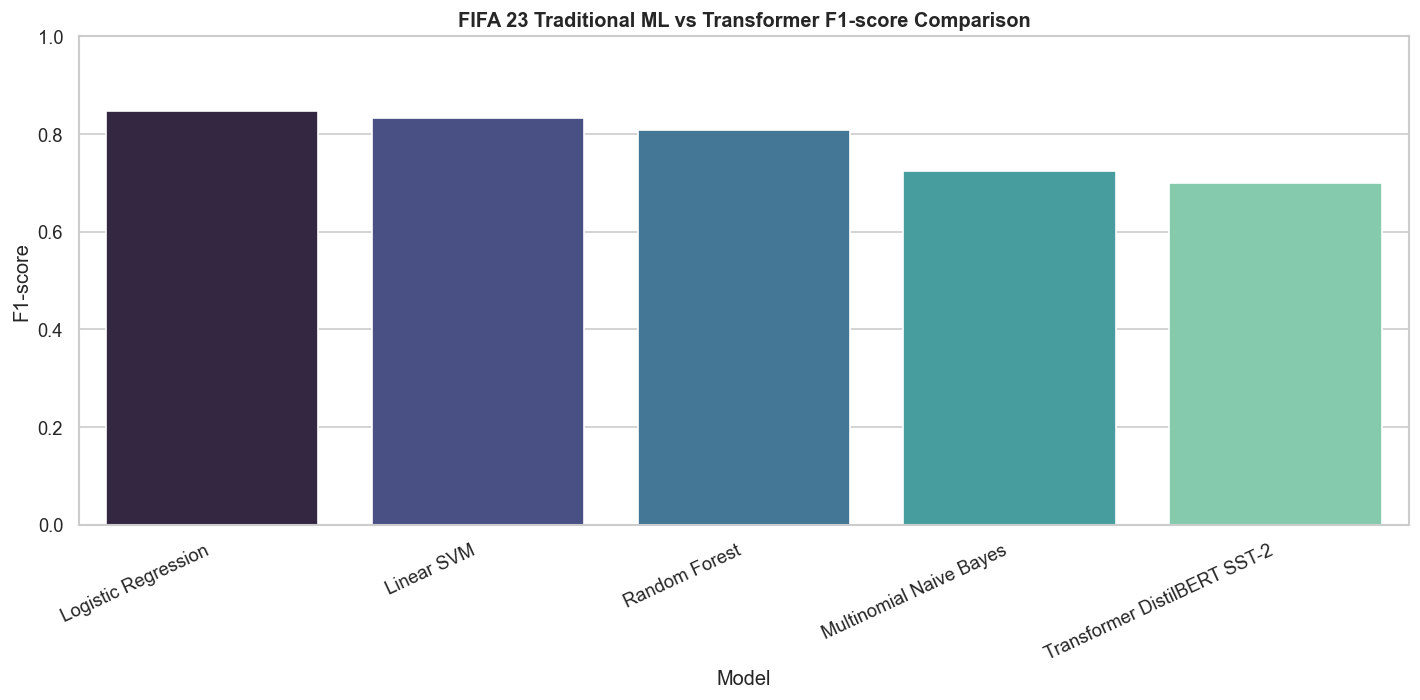

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\19_traditional_ml_vs_transformer_f1_comparison.png


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.856608,0.840296,0.853383,0.846789
1,Linear SVM,0.841397,0.819271,0.844791,0.831835
2,Random Forest,0.815461,0.780220,0.838883,0.808489
3,Multinomial Naive Bayes,0.779302,0.862120,0.624597,0.724385
4,Transformer DistilBERT SST-2,0.756500,0.818444,0.611410,0.699938


In [28]:
# Add transformer metrics to the same comparison table used for traditional models.
combined_model_results_df = pd.concat([model_results_df, transformer_results_df], ignore_index=True).dropna(subset=["F1-score"])
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_model_results_df.sort_values("F1-score", ascending=False), x="Model", y="F1-score", palette="mako")
plt.title("FIFA 23 Traditional ML vs Transformer F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
savefig("19_traditional_ml_vs_transformer_f1_comparison.png")
display(combined_model_results_df.sort_values("F1-score", ascending=False))


### 10.1 Trained BiLSTM Deep Learning Model

The DistilBERT pipeline above is a pretrained benchmark, so this subsection adds a neural network trained directly on the FIFA 23 review dataset. The model uses the same 80/20 train-test split created earlier, learns an Embedding representation from the cleaned review text, and applies a Bidirectional LSTM layer to capture word-order patterns in both directions.

The task remains binary because the supervised label is `voted_up`: `1` means Positive/Recommended and `0` means Negative/Not Recommended. A validation split and early stopping are used to reduce overfitting, while Accuracy, Precision, Recall, F1-score, a confusion matrix, and training-history plots are exported for the report.


### 10.4 Binary BiLSTM Setup

Initialize reusable output tables for the trained neural network.

In [29]:
# Train a true deep learning model on the FIFA 23 cleaned reviews.
# This is separate from the pretrained DistilBERT benchmark because the BiLSTM learns its weights from this dataset.
deep_learning_model_name = "BiLSTM Neural Network"
deep_learning_results_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
deep_learning_predictions_df = pd.DataFrame()
deep_learning_history_df = pd.DataFrame()



### 10.5 Train and Evaluate Binary BiLSTM

Train the Embedding + BiLSTM classifier directly on the FIFA 23 binary labels.

In [30]:
# Import TensorFlow/Keras and prepare reusable arrays for the binary BiLSTM.
deep_learning_available = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    keras.utils.set_random_seed(RANDOM_STATE)
    print(f"TensorFlow version: {tf.__version__}")

    MAX_TOKENS = 12000
    MAX_SEQUENCE_LENGTH = 120
    EMBEDDING_DIM = 64
    LSTM_UNITS = 48
    BATCH_SIZE = 64
    EPOCHS = 5

    train_text_array = X_train_text.fillna("").astype(str).to_numpy()
    test_text_array = X_test_text.fillna("").astype(str).to_numpy()
    y_train_array = y_train.astype(int).to_numpy()
    y_test_array = y_test.astype(int).to_numpy()
    deep_learning_available = True
except Exception as exc:
    print("BiLSTM deep learning model could not be completed in this runtime.")
    print("The setup cell installs TensorFlow. Rerun this section in Colab or another runtime with TensorFlow available if needed.")
    print(f"Error: {exc}")


TensorFlow version: 2.21.0


#### 10.5.1 Binary BiLSTM Architecture

Create the text vectorizer, Embedding layer, BiLSTM layer, dropout layers, and sigmoid output.

In [31]:
if deep_learning_available:
    text_vectorizer = layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode="int",
        output_sequence_length=MAX_SEQUENCE_LENGTH,
        standardize=None,
        name="text_vectorization",
    )
    text_vectorizer.adapt(train_text_array)

    bilstm_model = keras.Sequential(
        [
            text_vectorizer,
            layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBEDDING_DIM, mask_zero=True, name="embedding"),
            layers.Bidirectional(layers.LSTM(LSTM_UNITS), name="bidirectional_lstm"),
            layers.Dropout(0.40, name="dropout_after_lstm"),
            layers.Dense(32, activation="relu", name="dense_hidden"),
            layers.Dropout(0.30, name="dropout_hidden"),
            layers.Dense(1, activation="sigmoid", name="sentiment_output"),
        ],
        name="fifa23_bilstm_sentiment_classifier",
    )
    bilstm_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
    )
    early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)


#### 10.5.2 Train Binary BiLSTM

Train with a validation split and early stopping to reduce overfitting.

In [32]:
if deep_learning_available:
    history = bilstm_model.fit(
        train_text_array,
        y_train_array,
        validation_split=0.20,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1,
    )
    deep_learning_history_df = pd.DataFrame(history.history)
    deep_learning_history_df.insert(0, "epoch", np.arange(1, len(deep_learning_history_df) + 1))


Epoch 1/5


  1/201 ━━━━━━━━━━━━━━━━━━━━ 23:39 7s/step - accuracy: 0.3281 - loss: 0.6950 - precision: 0.3077 - recall: 0.6957

  2/201 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.3594 - loss: 0.6947 - precision: 0.3186 - recall: 0.6335

  3/201 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - accuracy: 0.3872 - loss: 0.6944 - precision: 0.3279 - recall: 0.5759

  4/201 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.4066 - loss: 0.6941 - precision: 0.3347 - recall: 0.5215

...

200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9039 - loss: 0.2566 - precision: 0.9070 - recall: 0.8825

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9039 - loss: 0.2565 - precision: 0.9070 - recall: 0.8826

201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accuracy: 0.9120 - loss: 0.2392 - precision: 0.9137 - recall: 0.8948 - val_accuracy: 0.8445 - val_loss: 0.4157 - val_precision: 0.8663 - val_recall: 0.7881


Epoch 3: early stopping


Restoring model weights from the end of the best epoch: 1.


#### 10.5.3 Evaluate Binary BiLSTM

Create metrics, predictions, confusion matrix, and training-history figures.

,Model,Accuracy,Precision,Recall,F1-score
0,BiLSTM Neural Network,0.840399,0.84795,0.799678,0.823107


              precision    recall  f1-score   support

    Negative       0.83      0.88      0.85      2148
    Positive       0.85      0.80      0.82      1862

    accuracy                           0.84      4010
   macro avg       0.84      0.84      0.84      4010
weighted avg       0.84      0.84      0.84      4010



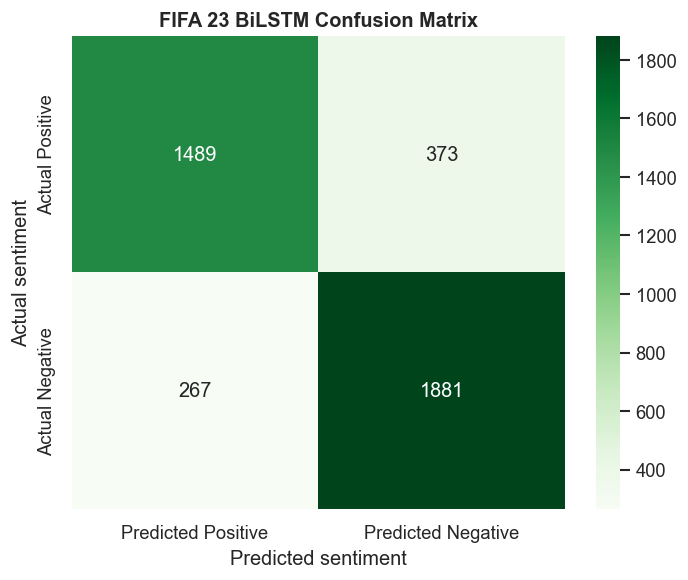

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\29_deep_learning_bilstm_confusion_matrix.png


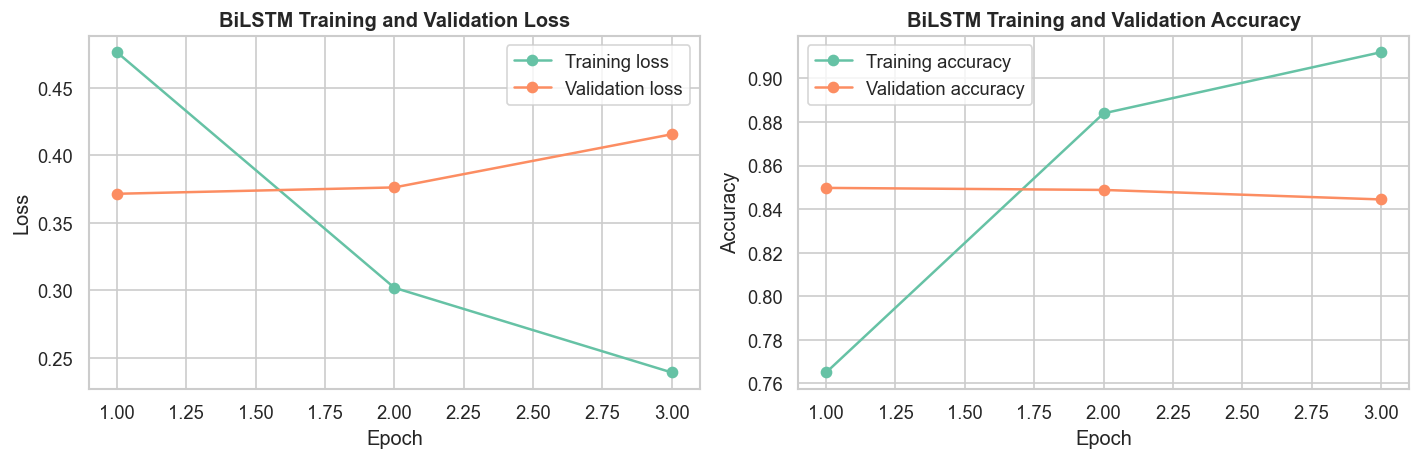

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\31_deep_learning_training_history.png


In [33]:
if deep_learning_available:
    bilstm_probabilities = bilstm_model.predict(test_text_array, batch_size=BATCH_SIZE, verbose=0).ravel()
    bilstm_predictions = (bilstm_probabilities >= 0.50).astype(int)

    deep_learning_results_df = pd.DataFrame([{
        "Model": deep_learning_model_name,
        "Accuracy": accuracy_score(y_test_array, bilstm_predictions),
        "Precision": precision_score(y_test_array, bilstm_predictions, zero_division=0),
        "Recall": recall_score(y_test_array, bilstm_predictions, zero_division=0),
        "F1-score": f1_score(y_test_array, bilstm_predictions, zero_division=0),
    }])
    display(deep_learning_results_df)
    print(classification_report(y_test_array, bilstm_predictions, target_names=["Negative", "Positive"], zero_division=0))

    deep_learning_predictions_df = pd.DataFrame({
        "review": X_test_text.values,
        "actual_sentiment_binary": y_test_array,
        "actual_sentiment": pd.Series(y_test_array).map({1: "Positive", 0: "Negative"}),
        "bilstm_probability_positive": bilstm_probabilities,
        "bilstm_prediction_binary": bilstm_predictions,
        "bilstm_prediction": pd.Series(bilstm_predictions).map({1: "Positive", 0: "Negative"}),
    })

    cm = confusion_matrix(y_test_array, bilstm_predictions, labels=[1, 0])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Predicted Positive", "Predicted Negative"], yticklabels=["Actual Positive", "Actual Negative"])
    plt.title("FIFA 23 BiLSTM Confusion Matrix")
    plt.xlabel("Predicted sentiment")
    plt.ylabel("Actual sentiment")
    savefig("29_deep_learning_bilstm_confusion_matrix.png")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(deep_learning_history_df["epoch"], deep_learning_history_df["loss"], marker="o", label="Training loss")
    axes[0].plot(deep_learning_history_df["epoch"], deep_learning_history_df["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("BiLSTM Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[1].plot(deep_learning_history_df["epoch"], deep_learning_history_df["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(deep_learning_history_df["epoch"], deep_learning_history_df["val_accuracy"], marker="o", label="Validation accuracy")
    axes[1].set_title("BiLSTM Training and Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    savefig("31_deep_learning_training_history.png")


### 10.6 Binary Deep Learning Comparison

Add the trained BiLSTM to the traditional ML and transformer comparison.

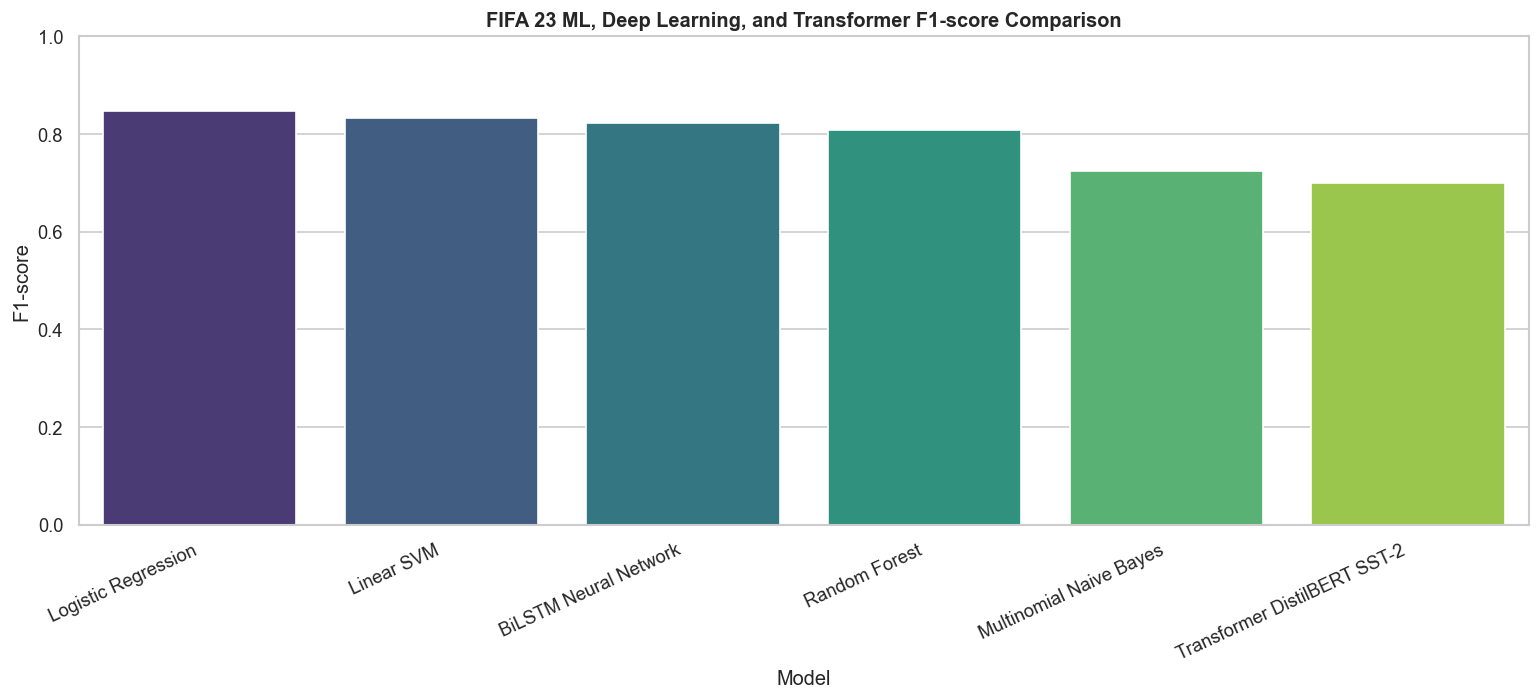

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\30_ml_deep_learning_transformer_f1_comparison.png


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.856608,0.840296,0.853383,0.846789
1,Linear SVM,0.841397,0.819271,0.844791,0.831835
2,BiLSTM Neural Network,0.840399,0.847950,0.799678,0.823107
3,Random Forest,0.815461,0.780220,0.838883,0.808489
4,Multinomial Naive Bayes,0.779302,0.862120,0.624597,0.724385
5,Transformer DistilBERT SST-2,0.756500,0.818444,0.611410,0.699938


In [34]:
# Build an updated comparison table that includes traditional ML, the trained BiLSTM, and the transformer benchmark.
comparison_parts = [model_results_df]
if not deep_learning_results_df.empty:
    comparison_parts.append(deep_learning_results_df)
if not transformer_results_df.empty:
    comparison_parts.append(transformer_results_df)

combined_model_results_with_deep_learning_df = (
    pd.concat(comparison_parts, ignore_index=True)
    .dropna(subset=["F1-score"])
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)

# Use the expanded table as the main combined result from this point onward.
combined_model_results_df = combined_model_results_with_deep_learning_df.copy()

plt.figure(figsize=(13, 6))
sns.barplot(
    data=combined_model_results_with_deep_learning_df,
    x="Model",
    y="F1-score",
    palette="viridis",
)
plt.title("FIFA 23 ML, Deep Learning, and Transformer F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
savefig("30_ml_deep_learning_transformer_f1_comparison.png")
display(combined_model_results_with_deep_learning_df)


## 11. Multi-Class Sentiment Classification (Additional Experiment)

The main assignment pipeline remains the binary Steam recommendation task because `voted_up` only contains `True` and `False`. However, the tutor feedback asks for a multi-class modelling comparison as well. Since Steam does not provide a manually annotated neutral label, this section creates a **VADER-derived weak-label target** from written review polarity:

- Negative: VADER compound score `<= -0.05`
- Neutral: VADER compound score between `-0.05` and `0.05`
- Positive: VADER compound score `>= 0.05`

These labels should not be interpreted as human ground truth. They are lexicon-generated labels used to compare how traditional machine learning and a trained deep learning model behave when the target has Positive, Neutral, and Negative written-sentiment categories. The binary models predict Steam recommendation behaviour, while the models in this section predict VADER-style written polarity.


### 11.1 Create VADER-Derived Multi-Class Labels

Create weak Positive, Neutral, and Negative labels from VADER compound thresholds.

,label,count,percentage
0,Negative,6659,33.211970
1,Neutral,6224,31.042394
2,Positive,7167,35.745636


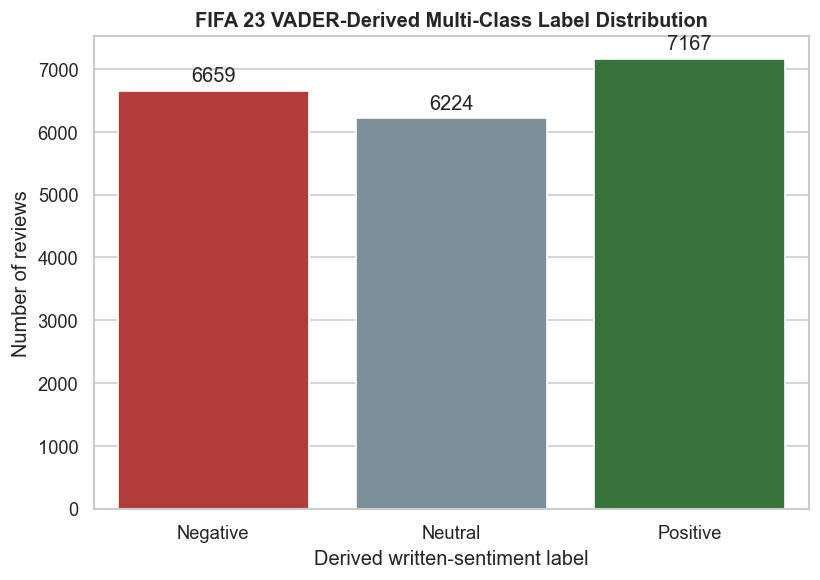

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\33_multiclass_vader_label_distribution.png


In [35]:
# Multi-class sentiment classification using VADER-derived weak labels.
# This experiment is separate from the main binary voted_up task.
from sklearn.metrics import precision_recall_fscore_support

MULTICLASS_LABEL_ORDER = ["Negative", "Neutral", "Positive"]
MULTICLASS_LABEL_TO_ID = {label: idx for idx, label in enumerate(MULTICLASS_LABEL_ORDER)}
MULTICLASS_ID_TO_LABEL = {idx: label for label, idx in MULTICLASS_LABEL_TO_ID.items()}

# Recalculate VADER compound if this section is run independently.
if "vader_compound" not in df_clean.columns:
    sia = SentimentIntensityAnalyzer()
    df_clean["vader_compound"] = df_clean["raw_review"].apply(lambda text: sia.polarity_scores(str(text))["compound"])

df_clean["vader_3class_label"] = np.select(
    [df_clean["vader_compound"] <= -0.05, df_clean["vader_compound"] >= 0.05],
    ["Negative", "Positive"],
    default="Neutral",
)
df_clean["vader_3class_encoded"] = df_clean["vader_3class_label"].map(MULTICLASS_LABEL_TO_ID).astype(int)

multiclass_vader_label_distribution_df = (
    df_clean["vader_3class_label"]
    .value_counts()
    .reindex(MULTICLASS_LABEL_ORDER, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)
multiclass_vader_label_distribution_df["percentage"] = (
    multiclass_vader_label_distribution_df["count"] / len(df_clean) * 100
)
display(multiclass_vader_label_distribution_df)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=multiclass_vader_label_distribution_df,
    x="label",
    y="count",
    order=MULTICLASS_LABEL_ORDER,
    palette=["#C62828", "#78909C", "#2E7D32"],
)
ax.set_title("FIFA 23 VADER-Derived Multi-Class Label Distribution")
ax.set_xlabel("Derived written-sentiment label")
ax.set_ylabel("Number of reviews")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
savefig("33_multiclass_vader_label_distribution.png")


### 11.2 Multi-Class Train/Test Split and TF-IDF

Create the stratified multi-class split and vectorize text with TF-IDF.

In [36]:
X_multi = df_clean["clean_review"].fillna("").astype(str)
y_multi = df_clean["vader_3class_encoded"]

X_multi_train_text, X_multi_test_text, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE,
)

multiclass_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.9,
)
X_multi_train_tfidf = multiclass_tfidf_vectorizer.fit_transform(X_multi_train_text)
X_multi_test_tfidf = multiclass_tfidf_vectorizer.transform(X_multi_test_text)


### 11.3 Multi-Class Model Definitions

Define multi-class classifiers and helper functions for confidence estimates.

In [37]:
multiclass_models = {
    "Multiclass Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced"),
    "Multiclass Linear SVM": LinearSVC(random_state=RANDOM_STATE, class_weight="balanced"),
    "Multiclass Random Forest": RandomForestClassifier(n_estimators=100, max_depth=60, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced_subsample"),
    "Multiclass Multinomial Naive Bayes": MultinomialNB(),
}


def confidence_from_model(model, features):
    """Return an approximate max confidence when the model exposes probabilities or decision scores."""
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        return probabilities.max(axis=1)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(features)
        scores = np.atleast_2d(scores)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        probabilities = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        return probabilities.max(axis=1)
    return np.full(features.shape[0], np.nan)


multiclass_rows = []
multiclass_detailed_rows = []
multiclass_predictions = {}
multiclass_confidences = {}
multiclass_trained_models = {}
y_multi_test_array = y_multi_test.astype(int).to_numpy()
y_multi_test_labels = pd.Series(y_multi_test_array).map(MULTICLASS_ID_TO_LABEL).to_numpy()


### 11.4 Train Traditional Multi-Class Models

Train and evaluate TF-IDF based multi-class classifiers.


Training Multiclass Logistic Regression...


              precision    recall  f1-score   support

    Negative       0.84      0.81      0.82      1332
     Neutral       0.84      0.94      0.89      1245
    Positive       0.88      0.82      0.85      1433

    accuracy                           0.85      4010
   macro avg       0.85      0.85      0.85      4010
weighted avg       0.85      0.85      0.85      4010



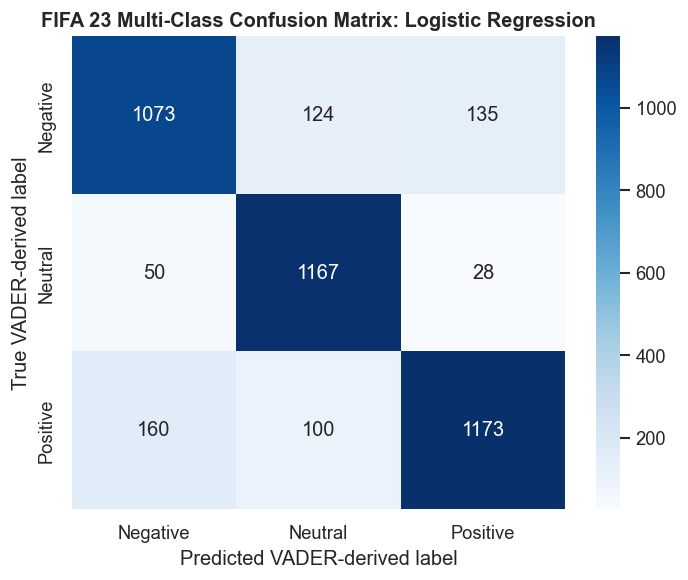

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\35_multiclass_logistic_regression_confusion_matrix.png

Training Multiclass Linear SVM...


              precision    recall  f1-score   support

    Negative       0.84      0.78      0.81      1332
     Neutral       0.85      0.93      0.89      1245
    Positive       0.85      0.83      0.84      1433

    accuracy                           0.85      4010
   macro avg       0.85      0.85      0.85      4010
weighted avg       0.85      0.85      0.85      4010



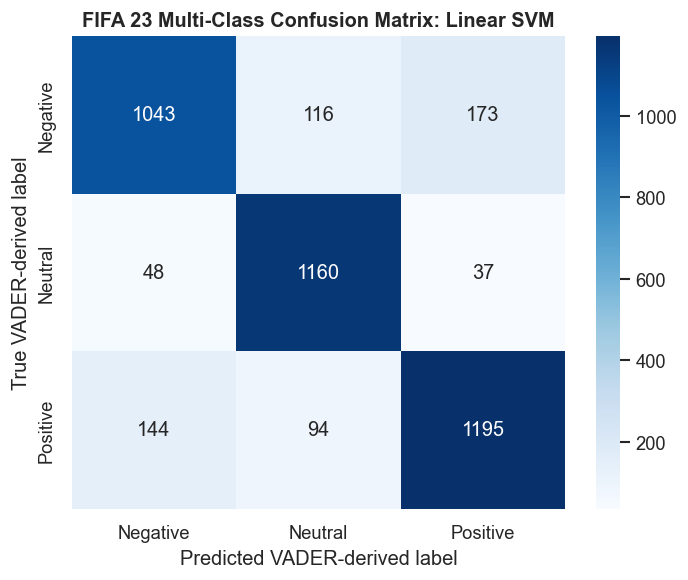

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\36_multiclass_linear_svm_confusion_matrix.png

Training Multiclass Random Forest...


              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76      1332
     Neutral       0.75      0.92      0.83      1245
    Positive       0.86      0.72      0.78      1433

    accuracy                           0.79      4010
   macro avg       0.79      0.79      0.79      4010
weighted avg       0.80      0.79      0.79      4010



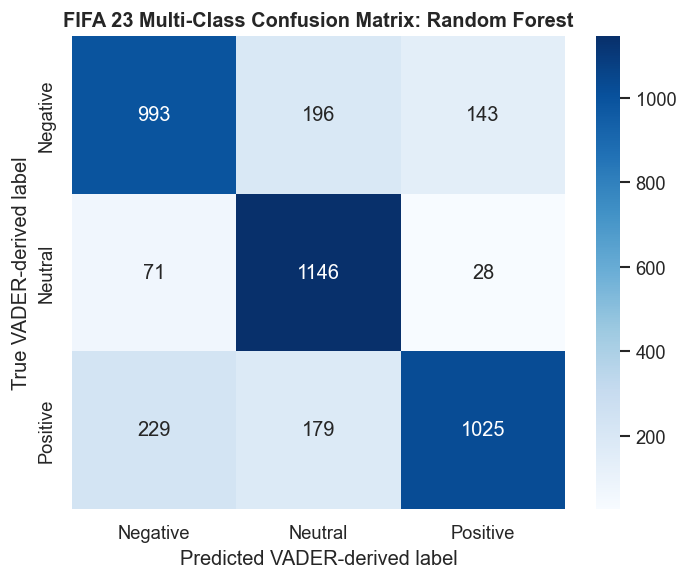

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\37_multiclass_random_forest_confusion_matrix.png

Training Multiclass Multinomial Naive Bayes...
              precision    recall  f1-score   support

    Negative       0.71      0.83      0.77      1332
     Neutral       0.85      0.38      0.52      1245
    Positive       0.61      0.81      0.70      1433

    accuracy                           0.68      4010
   macro avg       0.73      0.67      0.66      4010
weighted avg       0.72      0.68      0.67      4010



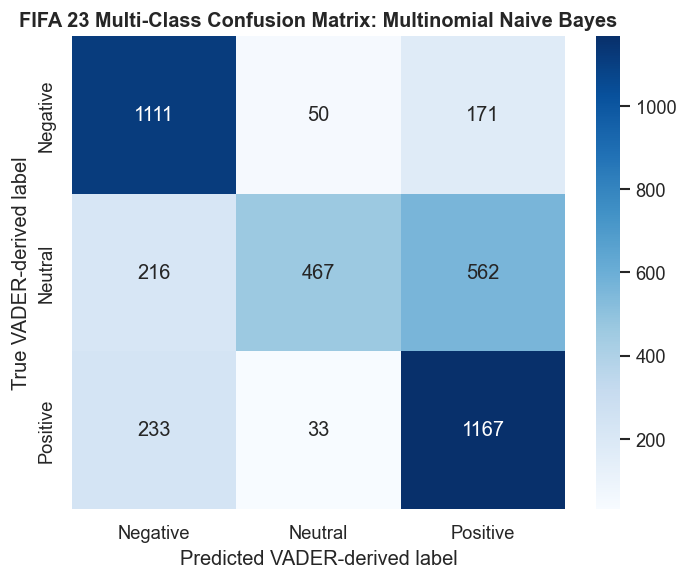

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\38_multiclass_naive_bayes_confusion_matrix.png


In [38]:
for model_name, model in multiclass_models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_multi_train_tfidf, y_multi_train)
    predicted = model.predict(X_multi_test_tfidf).astype(int)
    confidence = confidence_from_model(model, X_multi_test_tfidf)

    multiclass_trained_models[model_name] = model
    multiclass_predictions[model_name] = predicted
    multiclass_confidences[model_name] = confidence

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_multi_test_array,
        predicted,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_multi_test_array,
        predicted,
        labels=[0, 1, 2],
        average="weighted",
        zero_division=0,
    )
    multiclass_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_multi_test_array, predicted),
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "macro_f1": macro_f1,
            "weighted_precision": weighted_precision,
            "weighted_recall": weighted_recall,
            "weighted_f1": weighted_f1,
        }
    )

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_multi_test_array,
        predicted,
        labels=[0, 1, 2],
        zero_division=0,
    )
    for label_id, class_label in MULTICLASS_ID_TO_LABEL.items():
        multiclass_detailed_rows.append(
            {
                "model": model_name,
                "class_label": class_label,
                "precision": per_class_precision[label_id],
                "recall": per_class_recall[label_id],
                "f1_score": per_class_f1[label_id],
                "support": int(per_class_support[label_id]),
            }
        )

    print(classification_report(y_multi_test_array, predicted, labels=[0, 1, 2], target_names=MULTICLASS_LABEL_ORDER, zero_division=0))
    cm = confusion_matrix(y_multi_test_array, predicted, labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=MULTICLASS_LABEL_ORDER, yticklabels=MULTICLASS_LABEL_ORDER)
    plt.title(f"FIFA 23 Multi-Class Confusion Matrix: {model_name.replace('Multiclass ', '')}")
    plt.xlabel("Predicted VADER-derived label")
    plt.ylabel("True VADER-derived label")
    filename_map = {
        "Multiclass Logistic Regression": "35_multiclass_logistic_regression_confusion_matrix.png",
        "Multiclass Linear SVM": "36_multiclass_linear_svm_confusion_matrix.png",
        "Multiclass Random Forest": "37_multiclass_random_forest_confusion_matrix.png",
        "Multiclass Multinomial Naive Bayes": "38_multiclass_naive_bayes_confusion_matrix.png",
    }
    savefig(filename_map[model_name])


### 11.5 Train Multi-Class BiLSTM

Train the softmax BiLSTM model using the VADER-derived weak labels.

In [39]:
# Prepare TensorFlow/Keras and output containers for the multi-class BiLSTM.
multiclass_bilstm_available = False
multiclass_bilstm_results_df = pd.DataFrame()
multiclass_bilstm_training_history_df = pd.DataFrame()
multiclass_bilstm_predictions_df = pd.DataFrame()

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    keras.utils.set_random_seed(RANDOM_STATE)

    MAX_TOKENS = 12000
    MAX_SEQUENCE_LENGTH = 120
    EMBEDDING_DIM = 64
    LSTM_UNITS = 48
    BATCH_SIZE = 64
    EPOCHS = 5

    multi_train_array = X_multi_train_text.fillna("").astype(str).to_numpy()
    multi_test_array = X_multi_test_text.fillna("").astype(str).to_numpy()
    y_multi_train_array = y_multi_train.astype(int).to_numpy()
    multiclass_bilstm_available = True
except Exception as exc:
    print("Multi-class BiLSTM could not be completed in this runtime.")
    print("The setup cell installs TensorFlow. Rerun this section in Colab or another TensorFlow runtime if needed.")
    print(f"Error: {exc}")


#### 11.5.1 Multi-Class BiLSTM Architecture

Create the text vectorizer, Embedding layer, BiLSTM layer, dropout layers, and three-class softmax output.

In [40]:
if multiclass_bilstm_available:
    multiclass_text_vectorizer = layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode="int",
        output_sequence_length=MAX_SEQUENCE_LENGTH,
        standardize=None,
        name="multiclass_text_vectorization",
    )
    multiclass_text_vectorizer.adapt(multi_train_array)

    multiclass_bilstm_model = keras.Sequential(
        [
            multiclass_text_vectorizer,
            layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBEDDING_DIM, mask_zero=True, name="embedding"),
            layers.Bidirectional(layers.LSTM(LSTM_UNITS), name="bidirectional_lstm"),
            layers.Dropout(0.40, name="dropout_after_lstm"),
            layers.Dense(32, activation="relu", name="dense_hidden"),
            layers.Dropout(0.30, name="dropout_hidden"),
            layers.Dense(3, activation="softmax", name="sentiment_output"),
        ],
        name="fifa23_multiclass_bilstm_sentiment_classifier",
    )
    multiclass_bilstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    multiclass_early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)


#### 11.5.2 Train Multi-Class BiLSTM

Train the softmax neural model using the VADER-derived weak labels.

In [41]:
if multiclass_bilstm_available:
    multiclass_history = multiclass_bilstm_model.fit(
        multi_train_array,
        y_multi_train_array,
        validation_split=0.20,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[multiclass_early_stopping],
        verbose=1,
    )
    multiclass_bilstm_training_history_df = pd.DataFrame(multiclass_history.history)
    multiclass_bilstm_training_history_df.insert(0, "epoch", np.arange(1, len(multiclass_bilstm_training_history_df) + 1))


Epoch 1/5


  1/201 ━━━━━━━━━━━━━━━━━━━━ 23:50 7s/step - accuracy: 0.3594 - loss: 1.0970

  2/201 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.3477 - loss: 1.0969

  3/201 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.3394 - loss: 1.0969

  4/201 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.3395 - loss: 1.0968

...

200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9259 - loss: 0.2523

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9259 - loss: 0.2523

201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9305 - loss: 0.2393 - val_accuracy: 0.8320 - val_loss: 0.5120


Epoch 4: early stopping


Restoring model weights from the end of the best epoch: 2.


#### 11.5.3 Evaluate Multi-Class BiLSTM

Append BiLSTM metrics to the multi-class comparison tables and save its figures.

              precision    recall  f1-score   support

    Negative       0.78      0.83      0.81      1332
     Neutral       0.92      0.87      0.90      1245
    Positive       0.84      0.83      0.83      1433

    accuracy                           0.84      4010
   macro avg       0.85      0.84      0.85      4010
weighted avg       0.85      0.84      0.84      4010



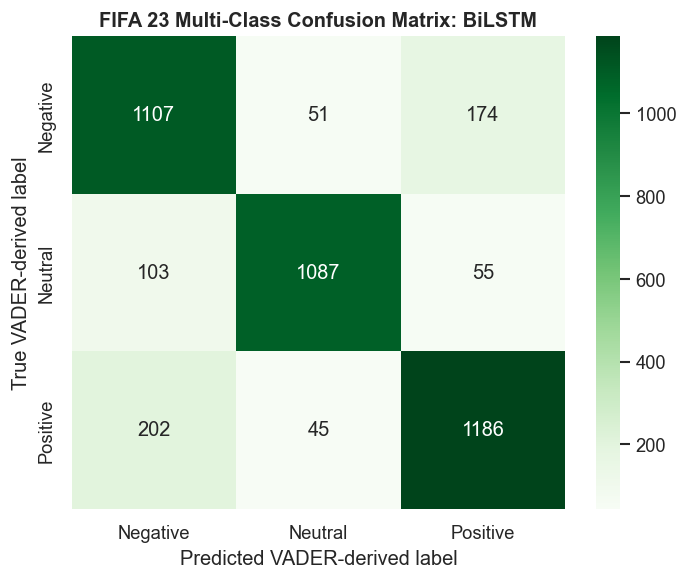

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\39_multiclass_bilstm_confusion_matrix.png


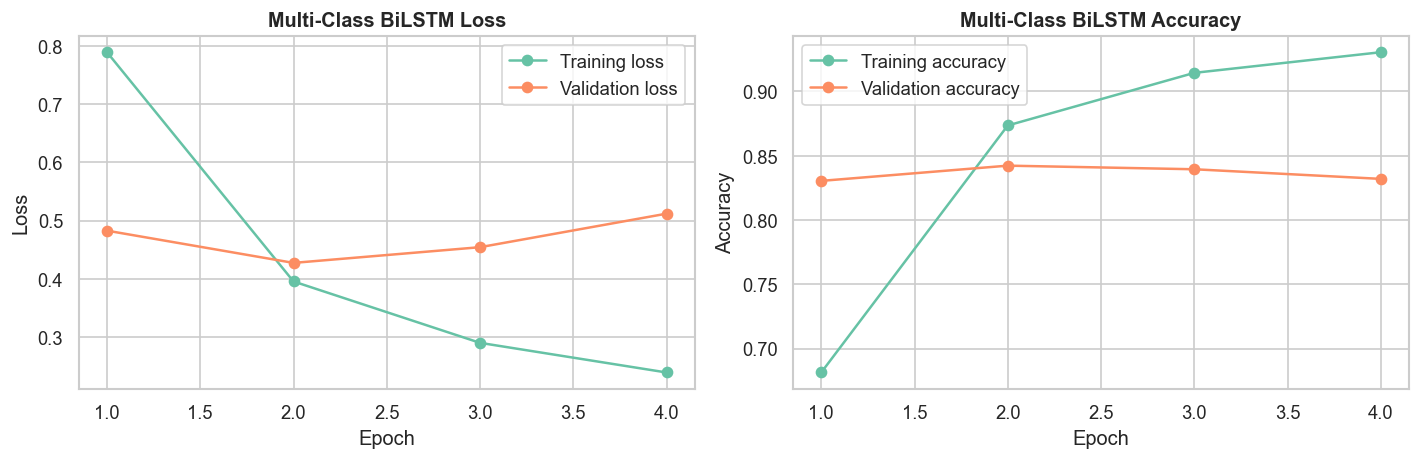

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\40_multiclass_bilstm_training_history.png


In [42]:
if multiclass_bilstm_available:
    bilstm_probabilities = multiclass_bilstm_model.predict(multi_test_array, batch_size=BATCH_SIZE, verbose=0)
    bilstm_predicted = bilstm_probabilities.argmax(axis=1).astype(int)
    bilstm_confidence = bilstm_probabilities.max(axis=1)
    multiclass_predictions["Multiclass BiLSTM Neural Network"] = bilstm_predicted
    multiclass_confidences["Multiclass BiLSTM Neural Network"] = bilstm_confidence

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_multi_test_array, bilstm_predicted, labels=[0, 1, 2], average="macro", zero_division=0)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_multi_test_array, bilstm_predicted, labels=[0, 1, 2], average="weighted", zero_division=0)
    multiclass_rows.append({
        "model": "Multiclass BiLSTM Neural Network",
        "accuracy": accuracy_score(y_multi_test_array, bilstm_predicted),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    })

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(y_multi_test_array, bilstm_predicted, labels=[0, 1, 2], zero_division=0)
    for label_id, class_label in MULTICLASS_ID_TO_LABEL.items():
        multiclass_detailed_rows.append({
            "model": "Multiclass BiLSTM Neural Network",
            "class_label": class_label,
            "precision": per_class_precision[label_id],
            "recall": per_class_recall[label_id],
            "f1_score": per_class_f1[label_id],
            "support": int(per_class_support[label_id]),
        })

    multiclass_bilstm_predictions_df = pd.DataFrame({
        "review": X_multi_test_text.values,
        "true_label": y_multi_test_labels,
        "predicted_label": pd.Series(bilstm_predicted).map(MULTICLASS_ID_TO_LABEL),
        "confidence": bilstm_confidence,
        "probability_negative": bilstm_probabilities[:, 0],
        "probability_neutral": bilstm_probabilities[:, 1],
        "probability_positive": bilstm_probabilities[:, 2],
    })

    print(classification_report(y_multi_test_array, bilstm_predicted, labels=[0, 1, 2], target_names=MULTICLASS_LABEL_ORDER, zero_division=0))
    cm = confusion_matrix(y_multi_test_array, bilstm_predicted, labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=MULTICLASS_LABEL_ORDER, yticklabels=MULTICLASS_LABEL_ORDER)
    plt.title("FIFA 23 Multi-Class Confusion Matrix: BiLSTM")
    plt.xlabel("Predicted VADER-derived label")
    plt.ylabel("True VADER-derived label")
    savefig("39_multiclass_bilstm_confusion_matrix.png")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(multiclass_bilstm_training_history_df["epoch"], multiclass_bilstm_training_history_df["loss"], marker="o", label="Training loss")
    axes[0].plot(multiclass_bilstm_training_history_df["epoch"], multiclass_bilstm_training_history_df["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Multi-Class BiLSTM Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[1].plot(multiclass_bilstm_training_history_df["epoch"], multiclass_bilstm_training_history_df["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(multiclass_bilstm_training_history_df["epoch"], multiclass_bilstm_training_history_df["val_accuracy"], marker="o", label="Validation accuracy")
    axes[1].set_title("Multi-Class BiLSTM Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    savefig("40_multiclass_bilstm_training_history.png")


### 11.6 Multi-Class Model Comparison

Compare macro F1-score and per-class F1-score across all multi-class models.

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Multiclass Logistic Regression,0.851122,0.851093,0.853822,0.851107,0.852034,0.851122,0.850264
1,Multiclass Linear SVM,0.847382,0.847261,0.849558,0.847318,0.847355,0.847382,0.846322
2,Multiclass BiLSTM Neural Network,0.842893,0.847002,0.843936,0.845035,0.845221,0.842893,0.843636
3,Multiclass Random Forest,0.789027,0.792819,0.793753,0.788323,0.795290,0.789027,0.787233
4,Multiclass Multinomial Naive Bayes,0.684539,0.725160,0.674520,0.662977,0.719677,0.684539,0.667011


,model,class_label,precision,recall,f1_score,support
0,Multiclass Logistic Regression,Negative,0.836321,0.805556,0.820650,1332
1,Multiclass Logistic Regression,Neutral,0.838965,0.937349,0.885432,1245
2,Multiclass Logistic Regression,Positive,0.877994,0.818562,0.847237,1433
3,Multiclass Linear SVM,Negative,0.844534,0.783033,0.812622,1332
4,Multiclass Linear SVM,Neutral,0.846715,0.931727,0.887189,1245
5,Multiclass Linear SVM,Positive,0.850534,0.833915,0.842142,1433
6,Multiclass Random Forest,Negative,0.767981,0.745495,0.756571,1332
7,Multiclass Random Forest,Neutral,0.753452,0.920482,0.828633,1245
8,Multiclass Random Forest,Positive,0.857023,0.715283,0.779764,1433
9,Multiclass Multinomial Naive Bayes,Negative,0.712179,0.834084,0.768326,1332


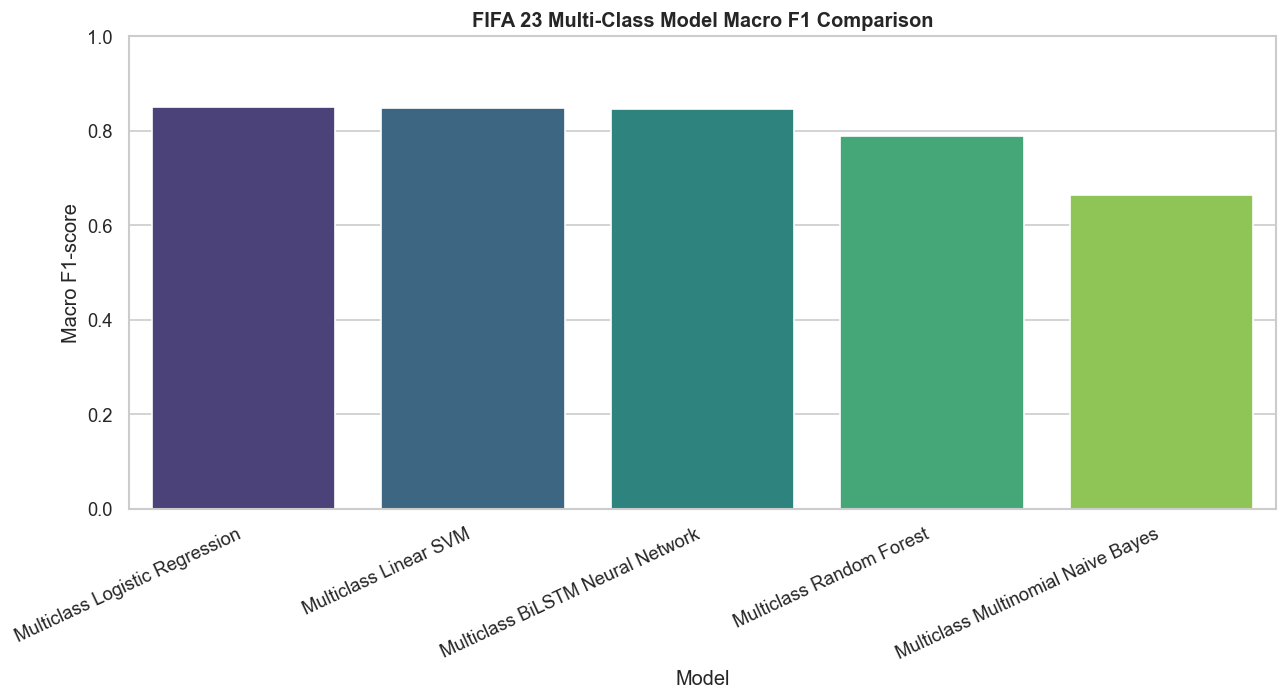

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\34_multiclass_model_macro_f1_comparison.png


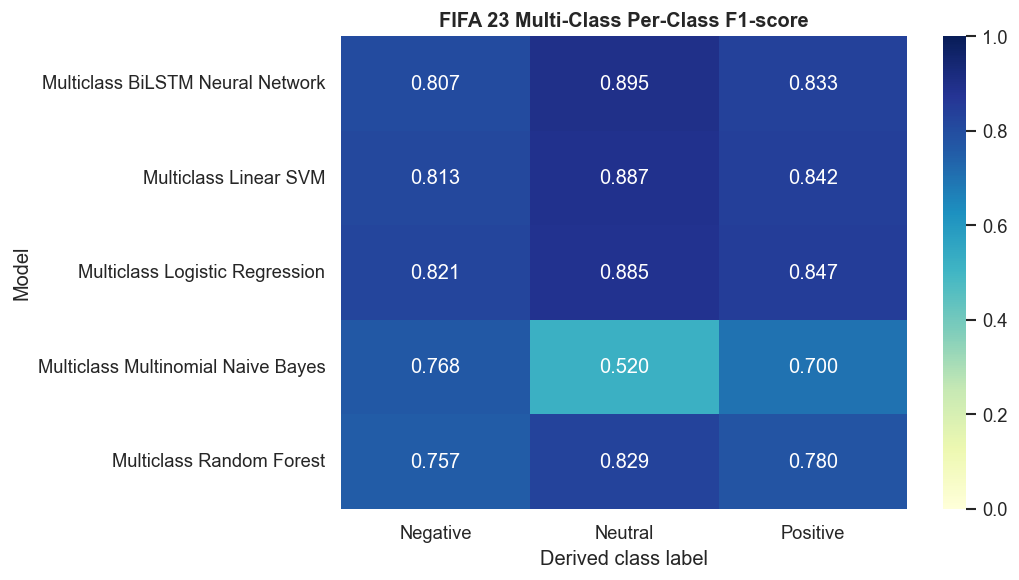

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\41_multiclass_per_class_f1_heatmap.png


In [43]:
multiclass_model_results_df = (
    pd.DataFrame(multiclass_rows)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
multiclass_model_results_detailed_df = pd.DataFrame(multiclass_detailed_rows)
display(multiclass_model_results_df)
display(multiclass_model_results_detailed_df)

plt.figure(figsize=(11, 6))
sns.barplot(data=multiclass_model_results_df, x="model", y="macro_f1", palette="viridis")
plt.title("FIFA 23 Multi-Class Model Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
savefig("34_multiclass_model_macro_f1_comparison.png")

if not multiclass_model_results_detailed_df.empty:
    per_class_heatmap = multiclass_model_results_detailed_df.pivot(index="model", columns="class_label", values="f1_score").reindex(columns=MULTICLASS_LABEL_ORDER)
    plt.figure(figsize=(9, 5))
    sns.heatmap(per_class_heatmap, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("FIFA 23 Multi-Class Per-Class F1-score")
    plt.xlabel("Derived class label")
    plt.ylabel("Model")
    savefig("41_multiclass_per_class_f1_heatmap.png")


### 11.7 Multi-Class Error Examples

Save compact examples where the best multi-class model disagrees with the weak label.

In [44]:
# Save compact error examples from the best model by macro F1.
multiclass_error_examples_rows = []
if not multiclass_model_results_df.empty:
    best_multiclass_model_name = multiclass_model_results_df.iloc[0]["model"]
    best_multiclass_predictions = multiclass_predictions[best_multiclass_model_name]
    best_multiclass_confidence = multiclass_confidences.get(best_multiclass_model_name, np.full(len(best_multiclass_predictions), np.nan))
    error_mask = best_multiclass_predictions != y_multi_test_array
    error_indices = np.where(error_mask)[0][:30]
    for idx in error_indices:
        true_label = MULTICLASS_ID_TO_LABEL[int(y_multi_test_array[idx])]
        predicted_label = MULTICLASS_ID_TO_LABEL[int(best_multiclass_predictions[idx])]
        multiclass_error_examples_rows.append(
            {
                "review": X_multi_test_text.iloc[idx],
                "true_derived_label": true_label,
                "predicted_label": predicted_label,
                "model_name": best_multiclass_model_name,
                "confidence": best_multiclass_confidence[idx],
                "notes": f"{true_label} weak label predicted as {predicted_label}; review may be short, mixed, or lexicon-ambiguous.",
            }
        )
multiclass_error_examples_df = pd.DataFrame(multiclass_error_examples_rows)
display(multiclass_error_examples_df)


,review,true_derived_label,predicted_label,model_name,confidence,notes
0,ea anti cheat trash paid shit able play play even official release great job ea,Positive,Negative,Multiclass Logistic Regression,0.583065,"Positive weak label predicted as Negative; review may be short, mixed, or lexicon-ambiguous."
1,dont want admit much ive spent,Negative,Positive,Multiclass Logistic Regression,0.436113,"Negative weak label predicted as Positive; review may be short, mixed, or lexicon-ambiguous."
2,no polish comment game fired polish display english language brazilian flag displayed next changing launch property spanish english french game downloads folder normal comment ...,Negative,Neutral,Multiclass Logistic Regression,0.534458,"Negative weak label predicted as Neutral; review may be short, mixed, or lexicon-ambiguous."
3,useless game doesnt even launch,Negative,Neutral,Multiclass Logistic Regression,0.488607,"Negative weak label predicted as Neutral; review may be short, mixed, or lexicon-ambiguous."
4,game semi decent quite slow liking tho,Positive,Neutral,Multiclass Logistic Regression,0.482160,"Positive weak label predicted as Neutral; review may be short, mixed, or lexicon-ambiguous."
5,really like career mode thing ultimate team bad constantly come tryhards cant play fine guess,Negative,Positive,Multiclass Logistic Regression,0.722861,"Negative weak label predicted as Positive; review may be short, mixed, or lexicon-ambiguous."
6,not best game okay,Negative,Positive,Multiclass Logistic Regression,0.847439,"Negative weak label predicted as Positive; review may be short, mixed, or lexicon-ambiguous."
7,dont sucre boot enable dont bother,Positive,Neutral,Multiclass Logistic Regression,0.484386,"Positive weak label predicted as Neutral; review may be short, mixed, or lexicon-ambiguous."
8,game released incompletely using window recommend never buy time fix error time play game,Positive,Negative,Multiclass Logistic Regression,0.746669,"Positive weak label predicted as Negative; review may be short, mixed, or lexicon-ambiguous."
9,no e basura,Neutral,Negative,Multiclass Logistic Regression,0.726635,"Neutral weak label predicted as Negative; review may be short, mixed, or lexicon-ambiguous."


## 12. Opinion Mining

This section extracts common opinion words and simple opinion phrases from positive and negative reviews.

The approach stays lightweight: POS tagging is used to identify adjectives, and adjective-noun pairs are used as simple opinion phrases or opinion targets. This is easier to explain than full dependency parsing, but it still gives more insight than a basic word cloud because it shows what players describe positively or negatively.


### 12.1 Opinion-Mining Helper Functions

Use POS tags to extract adjectives and simple adjective-noun phrases.

In [45]:
# Extract common adjective/opinion words and simple adjective-noun opinion phrases.
def get_pos_tags(text):
    '''Tokenize a cleaned review and return NLTK POS tags.'''
    tokens = [token for token in str(text).split() if len(token) > 2]
    if not tokens:
        return []
    try:
        return pos_tag(tokens)
    except Exception:
        return [(token, "") for token in tokens]


def top_adjectives(text_series, top_n=20):
    '''Return frequent adjectives, which often carry opinion in review text.'''
    counter = Counter()
    for text in text_series.astype(str):
        tagged_tokens = get_pos_tags(text)
        counter.update([word for word, tag in tagged_tokens if tag.startswith("JJ")])
    return pd.DataFrame(counter.most_common(top_n), columns=["opinion_word", "count"])


def top_opinion_phrases(text_series, top_n=20):
    '''Return simple adjective-noun pairs such as bad gameplay or good graphics.'''
    phrase_counter = Counter()
    for text in text_series.astype(str):
        tagged_tokens = get_pos_tags(text)
        for (word_1, tag_1), (word_2, tag_2) in zip(tagged_tokens, tagged_tokens[1:]):
            if tag_1.startswith("JJ") and (tag_2.startswith("NN") or tag_2.startswith("VB")):
                phrase_counter[f"{word_1} {word_2}"] += 1
    return pd.DataFrame(phrase_counter.most_common(top_n), columns=["opinion_phrase", "count"])


positive_reviews_clean = df_clean.loc[df_clean["sentiment_label"] == "Positive", "clean_review"]
negative_reviews_clean = df_clean.loc[df_clean["sentiment_label"] == "Negative", "clean_review"]


### 12.2 Positive and Negative Opinion Terms

Compare frequent opinion words and phrases by Steam recommendation sentiment.

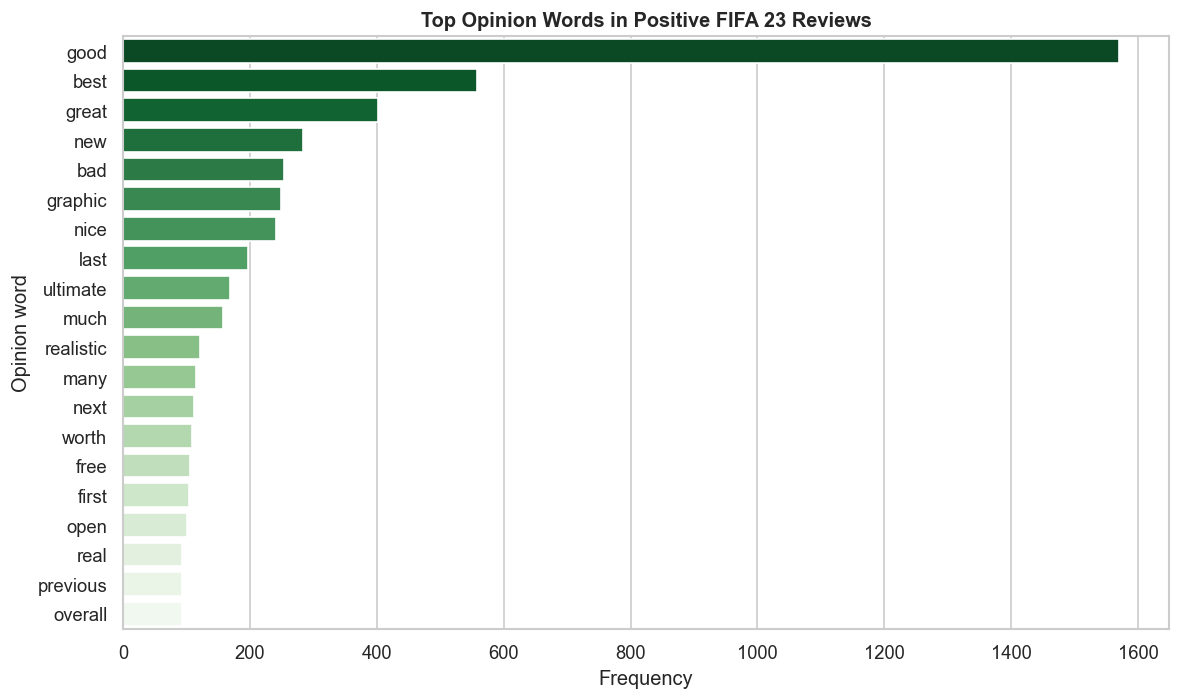

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\20_top_positive_opinion_words.png


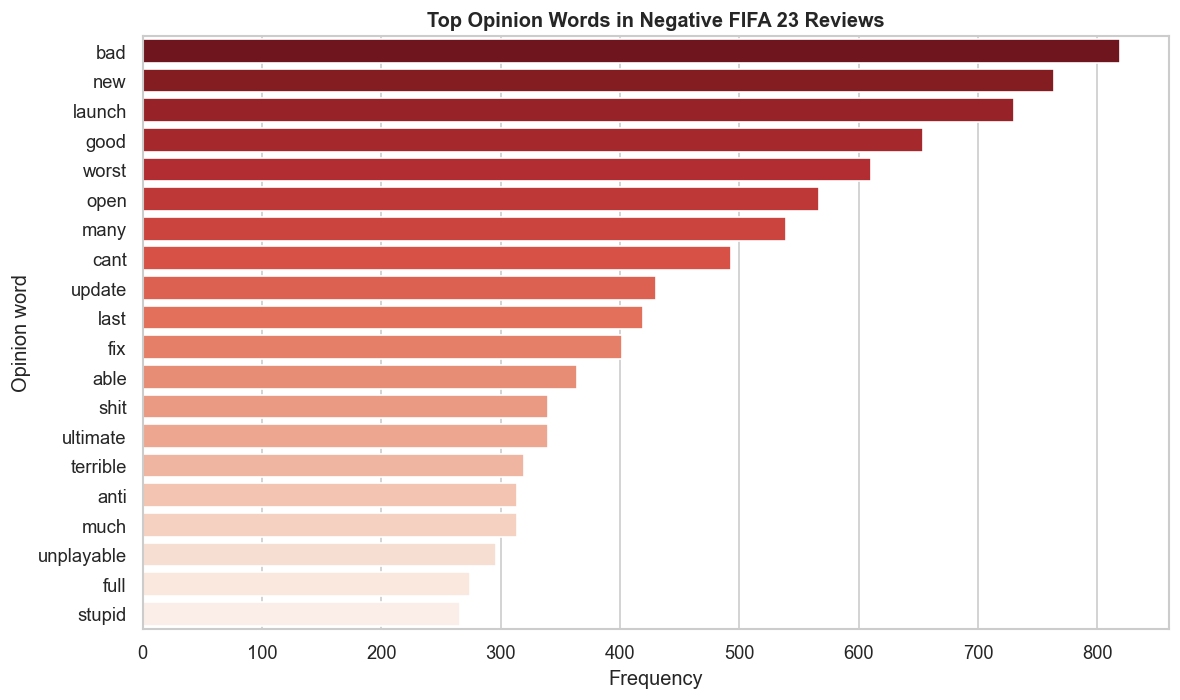

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\21_top_negative_opinion_words.png


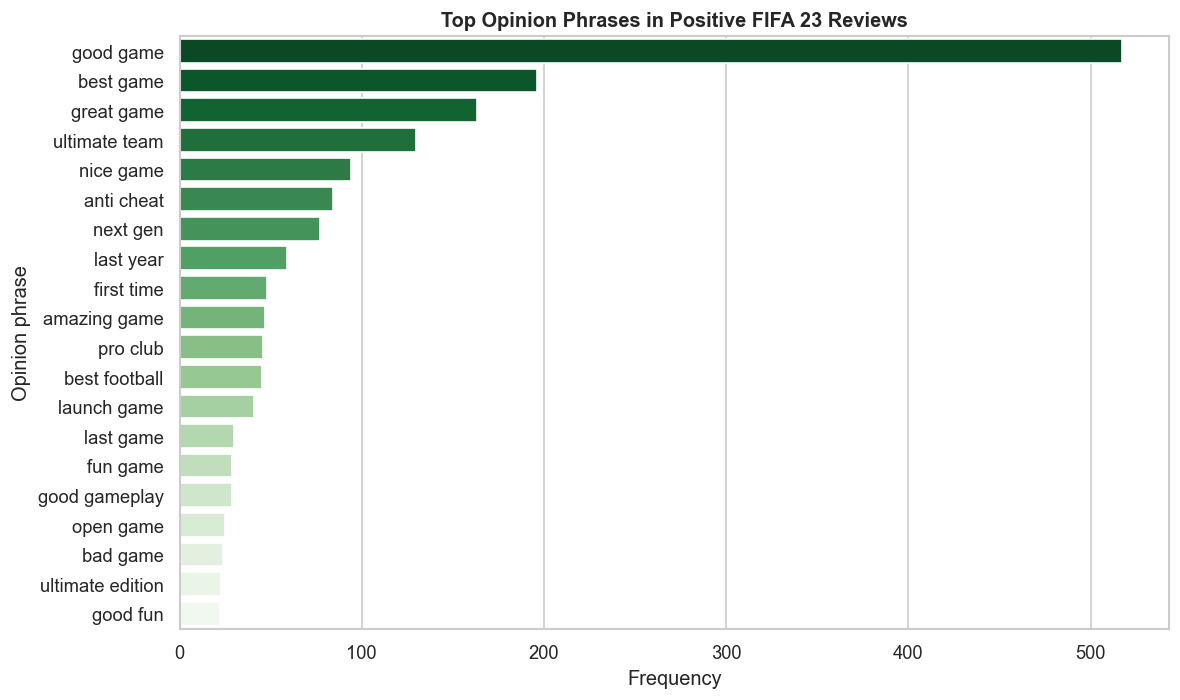

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\25_top_positive_opinion_phrases.png


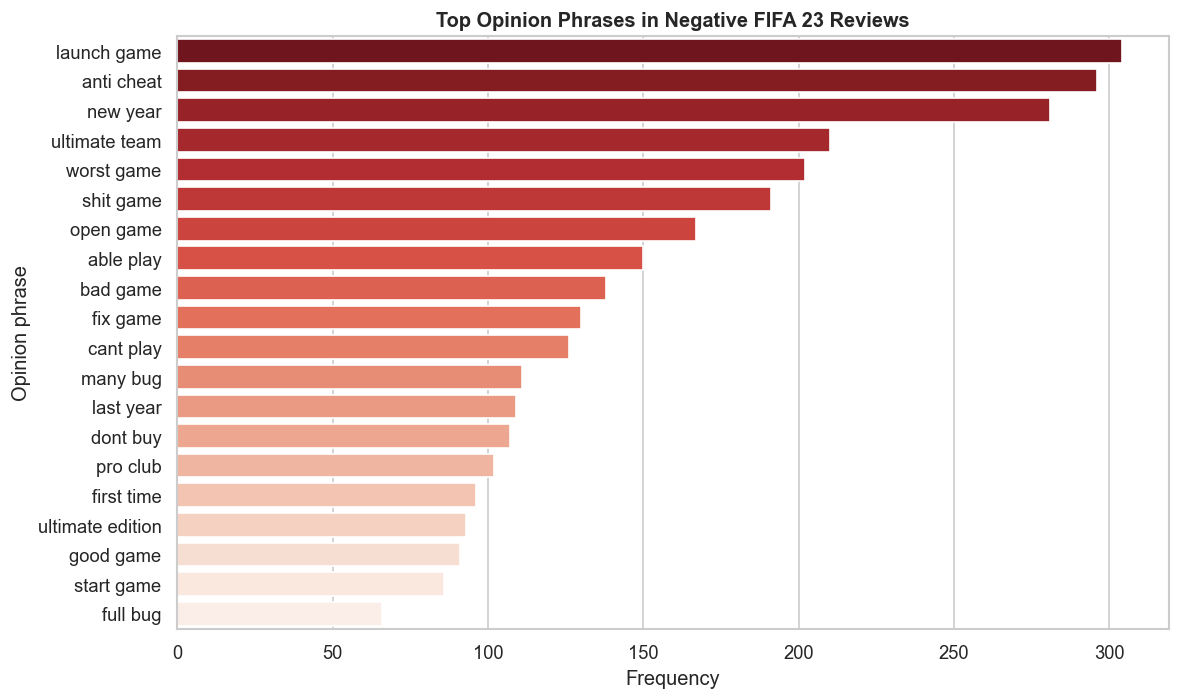

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\26_top_negative_opinion_phrases.png
Positive opinion words:


,opinion_word,count
0,good,1570
1,best,557
2,great,401
3,new,283
4,bad,253
5,graphic,248
6,nice,241
7,last,196
8,ultimate,168
9,much,158


Negative opinion words:


,opinion_word,count
0,bad,819
1,new,764
2,launch,730
3,good,654
4,worst,610
5,open,567
6,many,539
7,cant,493
8,update,430
9,last,419


Positive opinion phrases:


,opinion_phrase,count
0,good game,517
1,best game,196
2,great game,163
3,ultimate team,130
4,nice game,94
5,anti cheat,84
6,next gen,77
7,last year,59
8,first time,48
9,amazing game,47


Negative opinion phrases:


,opinion_phrase,count
0,launch game,304
1,anti cheat,296
2,new year,281
3,ultimate team,210
4,worst game,202
5,shit game,191
6,open game,167
7,able play,150
8,bad game,138
9,fix game,130


In [46]:
# Extract opinion vocabulary separately so positive and negative language can be compared.
positive_opinion_words = top_adjectives(positive_reviews_clean)
negative_opinion_words = top_adjectives(negative_reviews_clean)
positive_opinion_phrases = top_opinion_phrases(positive_reviews_clean)
negative_opinion_phrases = top_opinion_phrases(negative_reviews_clean)

plt.figure(figsize=(10, 6))
sns.barplot(data=positive_opinion_words, x="count", y="opinion_word", palette="Greens_r")
plt.title("Top Opinion Words in Positive FIFA 23 Reviews")
plt.xlabel("Frequency")
plt.ylabel("Opinion word")
savefig("20_top_positive_opinion_words.png")

plt.figure(figsize=(10, 6))
sns.barplot(data=negative_opinion_words, x="count", y="opinion_word", palette="Reds_r")
plt.title("Top Opinion Words in Negative FIFA 23 Reviews")
plt.xlabel("Frequency")
plt.ylabel("Opinion word")
savefig("21_top_negative_opinion_words.png")

plt.figure(figsize=(10, 6))
sns.barplot(data=positive_opinion_phrases, x="count", y="opinion_phrase", palette="Greens_r")
plt.title("Top Opinion Phrases in Positive FIFA 23 Reviews")
plt.xlabel("Frequency")
plt.ylabel("Opinion phrase")
savefig("25_top_positive_opinion_phrases.png")

plt.figure(figsize=(10, 6))
sns.barplot(data=negative_opinion_phrases, x="count", y="opinion_phrase", palette="Reds_r")
plt.title("Top Opinion Phrases in Negative FIFA 23 Reviews")
plt.xlabel("Frequency")
plt.ylabel("Opinion phrase")
savefig("26_top_negative_opinion_phrases.png")

print("Positive opinion words:")
display(positive_opinion_words)
print("Negative opinion words:")
display(negative_opinion_words)
print("Positive opinion phrases:")
display(positive_opinion_phrases)
print("Negative opinion phrases:")
display(negative_opinion_phrases)


### 12.3 Strong VADER Examples

Save strongly positive and strongly negative written-sentiment examples for report discussion.

In [47]:
# VADER extremes provide qualitative examples of strongly written sentiment.
strong_positive_examples_df = df_clean.sort_values("vader_compound", ascending=False)[["raw_review", "sentiment_label", "vader_compound"]].head(10)
strong_negative_examples_df = df_clean.sort_values("vader_compound", ascending=True)[["raw_review", "sentiment_label", "vader_compound"]].head(10)
display(strong_positive_examples_df)
display(strong_negative_examples_df)


,raw_review,sentiment_label,vader_compound
5851,[h1]F**K U EA AND HAVE A GOOD DAY :-)[/h1]\n\n韩国农历新年放那恶心谁呢？本来想着最后一代了支持一下，毕竟20玩的还挺好的，结果就这么恶心中国玩家是吗？测你们的马！\n\nBTW there's no lunar new year as well. The new year that global asia...,Negative,0.9999
24275,"As you see, [i]EA[/i] blessed ya boy with a review key when I asked. Did my stupendous writing woo them? The big follower count of my curator? 1018 hours in [i]FIFA 22[/i]? Per...",Positive,0.9996
19466,"This is a tough one for me to review, and a bit like football it is a game of two halves.\n\nFirst half\nGiven the absolute and unmitigated cluster truck that was (and still is...",Positive,0.9995
25140,"What a sublime end to the Fifa brand of football. \n\nIf you can get over your frustration, your anger and your feeling of resentment towards a company that has no excuses for ...",Positive,0.9988
20599,"DISCLAIMER 1: I haven't owned or played a FIFA game since 1998 (PS1, Blur song :). I have no interest or intention of playing Ultimate team. I realize the game might be a hot b...",Positive,0.9987
7555,This is the best game ever. I really recommend it to you because everyone needs to see the audacity of EA who wants 60$ for this amazing football simulator. The game is worth 1...,Negative,0.9985
13789,"I have played quite a few hours now, and think I have a better idea for this review. I wanted to feel like my time in career is worth it but after hours of career, it feels lik...",Negative,0.9984
14829,"If I trace back when I actually started to play Football video games, It was with the mid 90's. But Football games changed a lot at some point so I'd say the real start was aro...",Positive,0.9983
25696,"Edit - 1 week later, and still no fixes in sight. Getting less than 10 fps on a high end system. Sticking to Fifa 22 for now. \n\n\nFirst impressions review.\n\nThey really nee...",Negative,0.9982
25667,"EA, you did it again. You messed up the launch, again. Like you do every year. It is totally unacceptable that you charge almost 100 bucks for the Ultimate Edition that grants ...",Positive,0.9980


,raw_review,sentiment_label,vader_compound
17855,fuck this dog shit game. Don't make the blunder of buying this dog shit game.\nFuck you fifa\nFuck you fifa\nFuck you fifa\nFuck you fifa\nFuck you fifa\nFuck you fifa\nFuck yo...,Negative,-0.9990
15649,"My name is Walter Hartwell White. I live at 308 Negra Arroyo Lane, Albuquerque, New Mexico, 87104. This is my confession. If you're watching this tape, I'm probably dead, murde...",Positive,-0.9988
23000,This game gave me\n\nCancer - Breast\nCancer - Cervical\nCancer - Colon\nCancer - Endometrial\nCancer - Kidney\nCancer - Liver\nCancer - Multiple Myeloma\nCancer - Ovarian\nCan...,Negative,-0.9982
18466,"The worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst, worst fifa game of the whole series. \n...",Negative,-0.9980
12914,jakakokalareta marshalli asistencia marshalli meska paramueta para messi messi messi messi messi messi messi messi i menci messi ankara messi ankara messi ANKARA MESSI ANKARA M...,Positive,-0.9964
10857,"Fucking piece of shit, motherfucking EA again, fucking useless cunt game twat prick shit, never do another FIFA, you fucking fucks morons gay nigger trash, fuck you, fuckers fu...",Negative,-0.9964
1043,"I've been an avid fan of fifa games ever since I was a kid. I've been playing ever since fifa 14. To this day, I still think that 14 was the best I've ever played. Somehow it s...",Negative,-0.9961
18545,I thought when buying this game I'd disreguard any of the negative reviews as we all know what its like with FIFA every year we still buy it expecting something to have changed...,Negative,-0.9961
4820,"I sincerely hope every person who developped this game starts shitting themselves uncontrollably until the end of their days, because it is impossible to be a good person and d...",Negative,-0.9960
5740,"For the love of God, don't buy this if you haven't already. I've sunk 100s of hours into every FIFA since 17, but this year's game is so bad I won't even break 50, in fact I've...",Negative,-0.9952


## 13. Aspect-Based Sentiment Analysis

This section performs lightweight aspect-based sentiment analysis suitable for the assignment report.

Instead of training a complex ABSA model, it uses transparent FIFA/game aspect dictionaries. A review can mention multiple aspects, such as Gameplay and Servers/Online. Each aspect mention is summarized using both the Steam recommendation label (`voted_up`) and VADER written-text polarity. This makes the ABSA section stronger while keeping the method simple and explainable.


### 13.1 Aspect Dictionaries and Detection Helper

Define lightweight FIFA/game aspect keyword dictionaries.

In [48]:
# Detect predefined FIFA/game aspects and summarize positive vs negative sentiment for each aspect.
# Each aspect has a small keyword dictionary that can be reviewed and modified by future users.
aspects = {
    "Gameplay": ["gameplay", "mechanic", "control", "pace", "script", "scripting", "match", "player", "ball"],
    "Graphics": ["graphics", "visual", "animation", "realistic", "face", "stadium"],
    "Performance/Bugs": ["bug", "crash", "lag", "fps", "freeze", "error", "glitch", "stutter"],
    "Servers/Online": ["server", "online", "connection", "disconnect", "ping", "multiplayer"],
    "Career/Content": ["career", "mode", "ultimate", "fut", "content", "team", "pack"],
    "Price/Monetization": ["price", "money", "refund", "pay", "microtransaction", "ea"],
}


def detect_aspects_with_keywords(text):
    '''Return aspect and matched keyword pairs for a review.'''
    text = str(text).lower()
    found = []
    for aspect, keywords in aspects.items():
        for keyword in keywords:
            if re.search(r"\b" + re.escape(keyword) + r"s?\b", text):
                found.append((aspect, keyword))
                break
    return found



### 13.2 Expand Review-Level Aspect Mentions

Convert review-level matches into one row per detected aspect mention.

In [49]:
# Expand from one row per review to one row per detected aspect mention.
aspect_rows = []
for idx, row in df_clean.iterrows():
    for aspect, matched_keyword in detect_aspects_with_keywords(row["raw_review"]):
        aspect_rows.append({
            "review_index": idx,
            "aspect": aspect,
            "matched_keyword": matched_keyword,
            "sentiment_label": row["sentiment_label"],
            "sentiment_binary": row["sentiment_binary"],
            "vader_compound": row["vader_compound"],
            "vader_binary_label": row["vader_binary_label"],
            "raw_review": row["raw_review"],
        })

aspect_mentions_df = pd.DataFrame(aspect_rows)
print(f"Total aspect mentions detected: {len(aspect_mentions_df):,}")
display(aspect_mentions_df.head())


Total aspect mentions detected: 11,887


,review_index,aspect,matched_keyword,sentiment_label,sentiment_binary,vader_compound,vader_binary_label,raw_review
0,3,Price/Monetization,ea,Negative,0,0.0000,Positive,Fxxk u EAAntiCheat! Fxxk u EA!
1,6,Price/Monetization,money,Negative,0,-0.5346,Negative,"This game is terrible. Worse than 2022. Terrible interface, it never remembers your choices, and they changed up the game play a lot but it doesn't work. They should refund eve..."
2,8,Career/Content,career,Negative,0,0.5859,Positive,"If i want to play my career, i always have to start a new one to load the existing one.\nThis is no fun at all....."
3,16,Career/Content,ultimate,Positive,1,0.5267,Positive,pro clubs 10/10. ultimate team 0/10 pay to win
4,16,Price/Monetization,pay,Positive,1,0.5267,Positive,pro clubs 10/10. ultimate team 0/10 pay to win


### 13.3 Aspect Sentiment Summary

Summarize aspect sentiment using Steam recommendation labels and VADER polarity.

In [50]:
# Summarize every aspect using both Steam recommendation sentiment and written VADER polarity.
if aspect_mentions_df.empty:
    aspect_sentiment = pd.DataFrame({
        "aspect": list(aspects),
        "positive_count": 0,
        "negative_count": 0,
        "total_mentions": 0,
        "positive_percentage": np.nan,
        "negative_percentage": np.nan,
        "avg_vader_compound": np.nan,
        "vader_positive_count": 0,
        "vader_negative_count": 0,
        "vader_positive_percentage": np.nan,
    })
else:
    steam_counts = pd.crosstab(aspect_mentions_df["aspect"], aspect_mentions_df["sentiment_label"]).reindex(aspects.keys()).fillna(0)
    vader_counts = pd.crosstab(aspect_mentions_df["aspect"], aspect_mentions_df["vader_binary_label"]).reindex(aspects.keys()).fillna(0)
    for label in ["Positive", "Negative"]:
        if label not in steam_counts.columns:
            steam_counts[label] = 0
        if label not in vader_counts.columns:
            vader_counts[label] = 0

    aspect_sentiment = steam_counts[["Positive", "Negative"]].astype(int).reset_index()
    aspect_sentiment.columns = ["aspect", "positive_count", "negative_count"]
    aspect_sentiment["total_mentions"] = aspect_sentiment["positive_count"] + aspect_sentiment["negative_count"]
    aspect_sentiment["positive_percentage"] = np.where(
        aspect_sentiment["total_mentions"] > 0,
        aspect_sentiment["positive_count"] / aspect_sentiment["total_mentions"] * 100,
        np.nan,
    )
    aspect_sentiment["negative_percentage"] = np.where(
        aspect_sentiment["total_mentions"] > 0,
        aspect_sentiment["negative_count"] / aspect_sentiment["total_mentions"] * 100,
        np.nan,
    )

    vader_summary = aspect_mentions_df.groupby("aspect")["vader_compound"].mean().reindex(aspects.keys()).rename("avg_vader_compound").reset_index()
    vader_counts_df = vader_counts[["Positive", "Negative"]].astype(int).reset_index()
    vader_counts_df.columns = ["aspect", "vader_positive_count", "vader_negative_count"]
    aspect_sentiment = aspect_sentiment.merge(vader_summary, on="aspect", how="left").merge(vader_counts_df, on="aspect", how="left")
    aspect_sentiment["vader_positive_percentage"] = np.where(
        aspect_sentiment["total_mentions"] > 0,
        aspect_sentiment["vader_positive_count"] / aspect_sentiment["total_mentions"] * 100,
        np.nan,
    )

display(aspect_sentiment)


,aspect,positive_count,negative_count,total_mentions,positive_percentage,negative_percentage,avg_vader_compound,vader_positive_count,vader_negative_count,vader_positive_percentage
0,Gameplay,746,1451,2197,33.955394,66.044606,0.059052,1258,939,57.259900
1,Graphics,423,329,752,56.250000,43.750000,0.311553,549,203,73.005319
2,Performance/Bugs,447,1794,2241,19.946452,80.053548,-0.150856,930,1311,41.499331
3,Servers/Online,121,600,721,16.782247,83.217753,-0.098234,327,394,45.353675
4,Career/Content,629,1140,1769,35.556812,64.443188,0.107255,1067,702,60.316563
5,Price/Monetization,664,3543,4207,15.783218,84.216782,-0.103859,1966,2241,46.731638


### 13.4 Aspect Visualizations

Create aspect count, heatmap, polarity, and percentage figures.

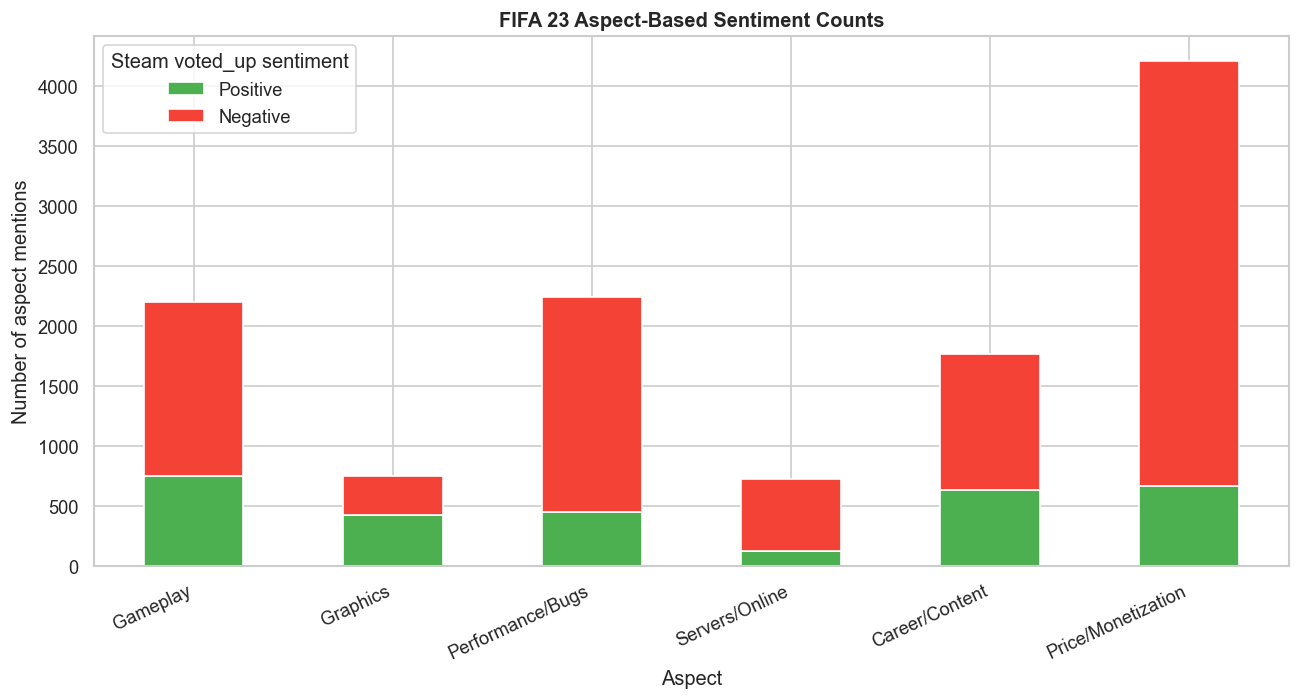

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\22_aspect_based_sentiment_stacked_bar.png


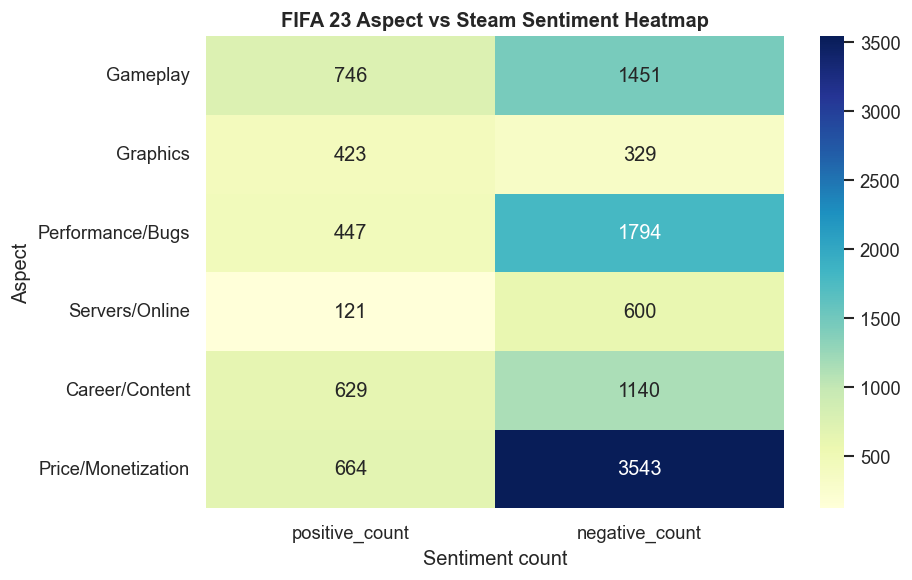

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\23_aspect_sentiment_heatmap.png


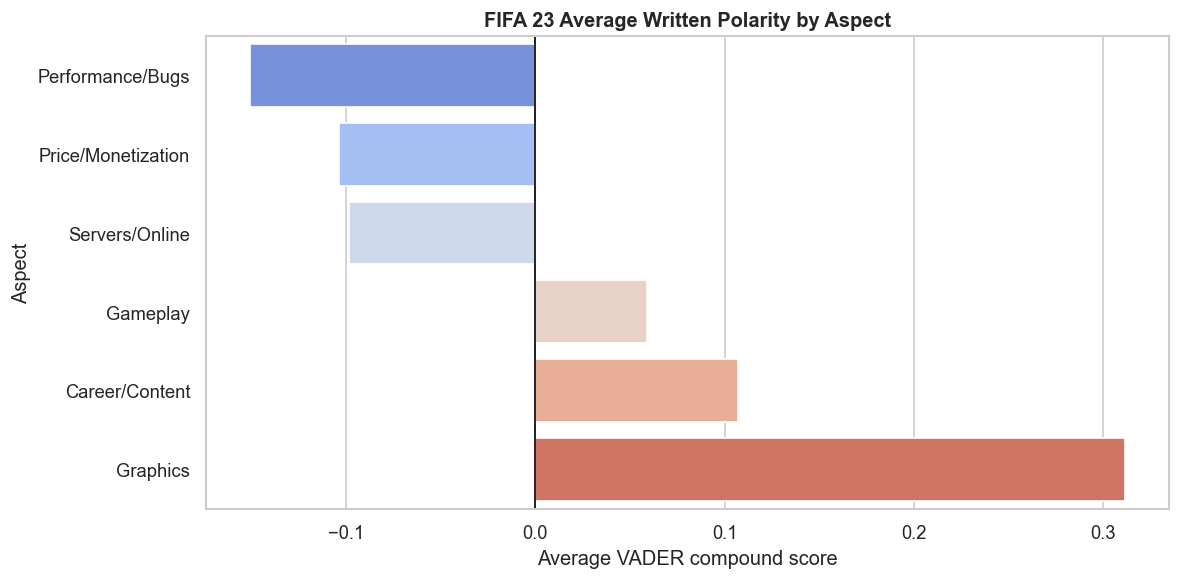

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\27_aspect_average_vader_polarity.png


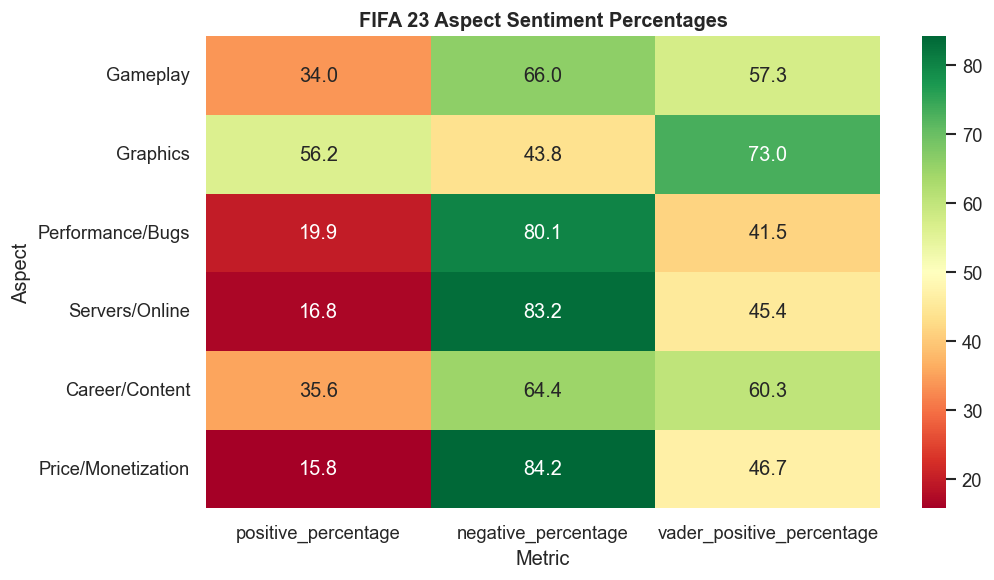

Saved: D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\figures\28_aspect_sentiment_percentage_heatmap.png


In [51]:
ax = aspect_sentiment.set_index("aspect")[["positive_count", "negative_count"]].plot(kind="bar", stacked=True, figsize=(11, 6), color=["#4CAF50", "#F44336"])
ax.set_title("FIFA 23 Aspect-Based Sentiment Counts")
ax.set_xlabel("Aspect")
ax.set_ylabel("Number of aspect mentions")
ax.legend(["Positive", "Negative"], title="Steam voted_up sentiment")
plt.xticks(rotation=25, ha="right")
savefig("22_aspect_based_sentiment_stacked_bar.png")

plt.figure(figsize=(8, 5))
sns.heatmap(aspect_sentiment.set_index("aspect")[["positive_count", "negative_count"]], annot=True, fmt="d", cmap="YlGnBu")
plt.title("FIFA 23 Aspect vs Steam Sentiment Heatmap")
plt.xlabel("Sentiment count")
plt.ylabel("Aspect")
savefig("23_aspect_sentiment_heatmap.png")

plt.figure(figsize=(10, 5))
sns.barplot(data=aspect_sentiment.sort_values("avg_vader_compound"), x="avg_vader_compound", y="aspect", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("FIFA 23 Average Written Polarity by Aspect")
plt.xlabel("Average VADER compound score")
plt.ylabel("Aspect")
savefig("27_aspect_average_vader_polarity.png")

plt.figure(figsize=(9, 5))
sns.heatmap(
    aspect_sentiment.set_index("aspect")[["positive_percentage", "negative_percentage", "vader_positive_percentage"]],
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=50,
)
plt.title("FIFA 23 Aspect Sentiment Percentages")
plt.xlabel("Metric")
plt.ylabel("Aspect")
savefig("28_aspect_sentiment_percentage_heatmap.png")


### 13.5 Aspect Example Reviews

Save example reviews for each aspect to support the report narrative.

In [52]:
# Save example reviews so the ABSA table can be supported with real review evidence.
aspect_examples = []
if not aspect_mentions_df.empty:
    for aspect in aspects:
        examples = aspect_mentions_df[aspect_mentions_df["aspect"] == aspect].copy()
        examples = examples.sort_values(["sentiment_label", "vader_compound"], ascending=[True, True])
        for _, row in examples.groupby("sentiment_label", group_keys=False).head(2).iterrows():
            aspect_examples.append({
                "aspect": aspect,
                "matched_keyword": row["matched_keyword"],
                "sentiment_label": row["sentiment_label"],
                "vader_compound": row["vader_compound"],
                "review": row["raw_review"],
            })
aspect_examples_df = pd.DataFrame(aspect_examples)
display(aspect_examples_df)


,aspect,matched_keyword,sentiment_label,vader_compound,review
0,Gameplay,pace,Negative,-0.9961,"I've been an avid fan of fifa games ever since I was a kid. I've been playing ever since fifa 14. To this day, I still think that 14 was the best I've ever played. Somehow it s..."
1,Gameplay,player,Negative,-0.9960,"I sincerely hope every person who developped this game starts shitting themselves uncontrollably until the end of their days, because it is impossible to be a good person and d..."
2,Gameplay,match,Positive,-0.9651,"I don't play Sport games, but i had to try if the guy who complained about the game not starting was true.\nAnd it was a fucking lie. Just like all of these Negative steam revi..."
3,Gameplay,gameplay,Positive,-0.9631,yes but on ultimate deafending is very bad . i dont know bucause of ping or bad gameplay. i am plying fifa from fifa 18 ..... fifa 23 online .deafending is not good for pro pla...
4,Graphics,graphics,Negative,-0.9961,"I've been an avid fan of fifa games ever since I was a kid. I've been playing ever since fifa 14. To this day, I still think that 14 was the best I've ever played. Somehow it s..."
5,Graphics,graphics,Negative,-0.9947,"HOW HAVE EA MADE SUCH DOGS DINNER OF THIS GAME\nMy socks should be able to run this shit\n\n***Post update two***\nStill absolutely shocking, game still runs terribly on lowes..."
6,Graphics,graphics,Positive,-0.9726,"Spent 70 Euros for this game to not start. ""Oh, yeah but just restart your computer."" Oh, do this and to that. \nHere are things i've done for this peice of shit to still not w..."
7,Graphics,graphics,Positive,-0.9496,"The gaming experience is very bad, I have an NVIDIA 1050 Ti graphics card, an intel 9900 k processor, 32 ram, and Windows 11 64 bits, but the gaming experience is bad, there i..."
8,Performance/Bugs,lag,Negative,-0.9961,"I've been an avid fan of fifa games ever since I was a kid. I've been playing ever since fifa 14. To this day, I still think that 14 was the best I've ever played. Somehow it s..."
9,Performance/Bugs,error,Negative,-0.9961,I thought when buying this game I'd disreguard any of the negative reviews as we all know what its like with FIFA every year we still buy it expecting something to have changed...


## 14. Final Results Summary

This section prints a concise report summary after all analysis steps have run. It gathers cleaned dataset size, sentiment distribution, best traditional model, transformer result, hypothesis findings, important terms, negative aspects, and a developer recommendation.


In [53]:
# Collect the most important final values into a report-ready printed summary.
positive_count = int((df_clean["sentiment_label"] == "Positive").sum())
negative_count = int((df_clean["sentiment_label"] == "Negative").sum())
best_f1 = float(model_results_df.iloc[0]["F1-score"])

if "deep_learning_results_df" in globals() and not deep_learning_results_df.empty and deep_learning_results_df["F1-score"].notna().any():
    deep_learning_summary = f"{deep_learning_results_df.iloc[0]['Model']} F1-score = {deep_learning_results_df.iloc[0]['F1-score']:.4f}"
else:
    deep_learning_summary = "Deep learning results unavailable in this runtime; rerun with TensorFlow available."

if not transformer_results_df.empty and transformer_results_df["F1-score"].notna().any():
    transformer_summary = f"{transformer_results_df.iloc[0]['Model']} F1-score = {transformer_results_df.iloc[0]['F1-score']:.4f}"
else:
    transformer_summary = "Transformer results unavailable in this runtime; rerun with internet/model access."

main_negative_aspects = aspect_sentiment[aspect_sentiment["total_mentions"] > 0].sort_values(["negative_percentage", "negative_count"], ascending=False).head(3)["aspect"].tolist()
recommendation = f"Prioritize improvements in {', '.join(main_negative_aspects)} because these aspects show the strongest negative sentiment signals." if main_negative_aspects else "Prioritize the aspects with the highest negative counts after rerunning aspect extraction."

print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"Final dataset size after cleaning: {len(df_clean):,} reviews")
print(f"Positive reviews: {positive_count:,} ({positive_count / len(df_clean):.2%})")
print(f"Negative reviews: {negative_count:,} ({negative_count / len(df_clean):.2%})")
print(f"Best traditional model and F1-score: {best_traditional_model_name}, {best_f1:.4f}")
print(f"Deep learning performance: {deep_learning_summary}")
print(f"Transformer performance: {transformer_summary}")
if "combined_model_results_with_deep_learning_df" in globals() and not combined_model_results_with_deep_learning_df.empty:
    print("\nUpdated model comparison including deep learning:")
    display(combined_model_results_with_deep_learning_df)
if "vader_3class_distribution_df" in globals() and not vader_3class_distribution_df.empty:
    print("\nVADER 3-class distribution:")
    display(vader_3class_distribution_df)
if "multiclass_model_results_df" in globals() and not multiclass_model_results_df.empty:
    best_multi = multiclass_model_results_df.iloc[0]
    best_multi_model = best_multi["model"]
    best_multi_macro_f1 = best_multi["macro_f1"]
    print(f"\nBest multi-class model by macro F1: {best_multi_model}, {best_multi_macro_f1:.4f}")
    display(multiclass_model_results_df)
if "multiclass_vader_label_distribution_df" in globals() and not multiclass_vader_label_distribution_df.empty:
    print("\nVADER-derived multi-class label distribution:")
    display(multiclass_vader_label_distribution_df)
print("\nKey hypothesis findings:")
for _, row in hypothesis_results_df.iterrows():
    print(f"- {row['Hypothesis']}: {row['Interpretation']}")
print("\nTop positive TF-IDF terms:", ", ".join(top_positive_terms["term"].head(10)))
print("Top negative TF-IDF terms:", ", ".join(top_negative_terms["term"].head(10)))
print("Top positive opinion phrases:", ", ".join(positive_opinion_phrases["opinion_phrase"].head(5)))
print("Top negative opinion phrases:", ", ".join(negative_opinion_phrases["opinion_phrase"].head(5)))
print("Main aspects with highest negative sentiment:", ", ".join(main_negative_aspects) if main_negative_aspects else "No aspect mentions detected.")
print("Main recommendation for game developers:", recommendation)


FINAL RESULTS SUMMARY
Final dataset size after cleaning: 20,050 reviews
Positive reviews: 9,310 (46.43%)
Negative reviews: 10,740 (53.57%)
Best traditional model and F1-score: Logistic Regression, 0.8468
Deep learning performance: BiLSTM Neural Network F1-score = 0.8231
Transformer performance: Transformer DistilBERT SST-2 F1-score = 0.6999

Updated model comparison including deep learning:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.856608,0.840296,0.853383,0.846789
1,Linear SVM,0.841397,0.819271,0.844791,0.831835
2,BiLSTM Neural Network,0.840399,0.847950,0.799678,0.823107
3,Random Forest,0.815461,0.780220,0.838883,0.808489
4,Multinomial Naive Bayes,0.779302,0.862120,0.624597,0.724385
5,Transformer DistilBERT SST-2,0.756500,0.818444,0.611410,0.699938



VADER 3-class distribution:


,vader_label,review_count,percentage
0,Positive,7167,35.745636
1,Neutral,6224,31.042394
2,Negative,6659,33.211970



Best multi-class model by macro F1: Multiclass Logistic Regression, 0.8511


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Multiclass Logistic Regression,0.851122,0.851093,0.853822,0.851107,0.852034,0.851122,0.850264
1,Multiclass Linear SVM,0.847382,0.847261,0.849558,0.847318,0.847355,0.847382,0.846322
2,Multiclass BiLSTM Neural Network,0.842893,0.847002,0.843936,0.845035,0.845221,0.842893,0.843636
3,Multiclass Random Forest,0.789027,0.792819,0.793753,0.788323,0.795290,0.789027,0.787233
4,Multiclass Multinomial Naive Bayes,0.684539,0.725160,0.674520,0.662977,0.719677,0.684539,0.667011



VADER-derived multi-class label distribution:


,label,count,percentage
0,Negative,6659,33.211970
1,Neutral,6224,31.042394
2,Positive,7167,35.745636



Key hypothesis findings:
- H1: Players with higher recent playtime are more likely to leave positive reviews: p=5.921e-121; Positive median=5.07, Negative median=0.32. Significant difference detected.
- H2: Players who own more games are more likely to provide negative reviews: p=7.634e-187; Positive median=16.00, Negative median=30.00. Significant difference detected.
- H3: Sentiment changes over time: p=7.256e-43; sentiment distribution changes significantly over time.
- H4: Written sentiment agrees with Steam voted_up recommendation: VADER binary sentiment agrees with voted_up for 69.36% of cleaned reviews. VADER 3-class labels are reported descriptively, but binary conversion is required for direct comparison because Steam voted_up has no neutral ground-truth class.

Top positive TF-IDF terms: game, good, fun, best, good game, love, like, play, nice, great
Top negative TF-IDF terms: game, ea, not, even, play, launch, shit, buy, time, bad
Top positive opinion phrases: good game, be

## 15. Export Outputs

This final section saves all reusable analysis outputs. These files are intended for direct insertion or reference in the final report, including model metrics, hypothesis results, aspect sentiment results, error-analysis examples, transformer sample predictions if available, and the cleaned review dataset.


### 15.1 Export Main Result Tables

Save model, hypothesis, aspect, and error-analysis outputs.

In [54]:
# Export all generated tables and cleaned data for report use.
# Model and statistical result tables.
model_results_df.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
combined_model_results_df.to_csv(OUTPUT_DIR / "combined_model_results.csv", index=False)
if "combined_model_results_with_deep_learning_df" in globals() and not combined_model_results_with_deep_learning_df.empty:
    combined_model_results_with_deep_learning_df.to_csv(OUTPUT_DIR / "combined_model_results_with_deep_learning.csv", index=False)
hypothesis_results_df.to_csv(OUTPUT_DIR / "hypothesis_results.csv", index=False)
if "vader_3class_distribution_df" in globals() and not vader_3class_distribution_df.empty:
    vader_3class_distribution_df.to_csv(OUTPUT_DIR / "vader_3class_distribution.csv", index=False)
if "vader_binary_distribution_df" in globals() and not vader_binary_distribution_df.empty:
    vader_binary_distribution_df.to_csv(OUTPUT_DIR / "vader_binary_distribution.csv", index=False)
aspect_sentiment.to_csv(OUTPUT_DIR / "aspect_sentiment_results.csv", index=False)
error_analysis_df.to_csv(OUTPUT_DIR / "sample_error_analysis.csv", index=False)


### 15.2 Export Opinion Mining and Cleaned Data

Save opinion-mining tables and the final cleaned dataset.

In [55]:
# Opinion mining outputs.
positive_opinion_words.to_csv(OUTPUT_DIR / "positive_opinion_words.csv", index=False)
negative_opinion_words.to_csv(OUTPUT_DIR / "negative_opinion_words.csv", index=False)
positive_opinion_phrases.to_csv(OUTPUT_DIR / "positive_opinion_phrases.csv", index=False)
negative_opinion_phrases.to_csv(OUTPUT_DIR / "negative_opinion_phrases.csv", index=False)
strong_positive_examples_df.to_csv(OUTPUT_DIR / "strong_positive_examples.csv", index=False)
strong_negative_examples_df.to_csv(OUTPUT_DIR / "strong_negative_examples.csv", index=False)

# Cleaned dataset with both raw_review and clean_review for future analysis.
df_clean.to_csv(OUTPUT_DIR / "final_cleaned_fifa23_reviews.csv", index=False)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)


### 15.3 Export Multi-Class Outputs

Save all VADER-derived multi-class experiment artifacts.

In [56]:
# Multi-class outputs are written only when the additional weak-label experiment ran successfully.
if "multiclass_vader_label_distribution_df" in globals() and not multiclass_vader_label_distribution_df.empty:
    multiclass_vader_label_distribution_df.to_csv(OUTPUT_DIR / "multiclass_vader_label_distribution.csv", index=False)
if "multiclass_model_results_df" in globals() and not multiclass_model_results_df.empty:
    multiclass_model_results_df.to_csv(OUTPUT_DIR / "multiclass_model_results.csv", index=False)
if "multiclass_model_results_detailed_df" in globals() and not multiclass_model_results_detailed_df.empty:
    multiclass_model_results_detailed_df.to_csv(OUTPUT_DIR / "multiclass_model_results_detailed.csv", index=False)
if "multiclass_bilstm_training_history_df" in globals() and not multiclass_bilstm_training_history_df.empty:
    multiclass_bilstm_training_history_df.to_csv(OUTPUT_DIR / "multiclass_bilstm_training_history.csv", index=False)
if "multiclass_bilstm_predictions_df" in globals() and not multiclass_bilstm_predictions_df.empty:
    multiclass_bilstm_predictions_df.to_csv(OUTPUT_DIR / "multiclass_bilstm_predictions.csv", index=False)
if "multiclass_error_examples_df" in globals() and not multiclass_error_examples_df.empty:
    multiclass_error_examples_df.to_csv(OUTPUT_DIR / "multiclass_error_examples.csv", index=False)


### 15.4 Export Deep Learning Outputs

Save the binary BiLSTM result, history, and prediction files.

In [57]:
# Deep learning outputs are written only when the BiLSTM section ran successfully.
if "deep_learning_results_df" in globals() and not deep_learning_results_df.empty:
    deep_learning_results_df.to_csv(OUTPUT_DIR / "deep_learning_bilstm_results.csv", index=False)
if "deep_learning_history_df" in globals() and not deep_learning_history_df.empty:
    deep_learning_history_df.to_csv(OUTPUT_DIR / "deep_learning_bilstm_training_history.csv", index=False)
if "deep_learning_predictions_df" in globals() and not deep_learning_predictions_df.empty:
    deep_learning_predictions_df.to_csv(OUTPUT_DIR / "deep_learning_bilstm_predictions.csv", index=False)


### 15.5 Export Optional Section Outputs

Save transformer and ABSA detail files when those sections ran successfully.

In [58]:
# Optional outputs are written only when their sections ran successfully.
if not transformer_predictions_df.empty:
    transformer_predictions_df.to_csv(OUTPUT_DIR / "transformer_sample_predictions.csv", index=False)
if not transformer_error_examples_df.empty:
    transformer_error_examples_df.to_csv(OUTPUT_DIR / "transformer_error_examples.csv", index=False)
if not transformer_confidence_summary_df.empty:
    transformer_confidence_summary_df.to_csv(OUTPUT_DIR / "transformer_confidence_summary.csv", index=False)
if not aspect_mentions_df.empty:
    aspect_mentions_df.to_csv(OUTPUT_DIR / "aspect_mentions.csv", index=False)
if not aspect_examples_df.empty:
    aspect_examples_df.to_csv(OUTPUT_DIR / "aspect_example_reviews.csv", index=False)


### 15.6 List Exported Files

Print the generated CSV and figure files for quick verification.

In [59]:
print("Export complete. Output CSV files:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"- {path}")
print("\nFigure files:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"- {path}")


Export complete. Output CSV files:
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\aspect_example_reviews.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\aspect_mentions.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\aspect_sentiment_results.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\combined_model_results.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\combined_model_results_with_deep_learning.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\cross_validation_results.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\outputs\deep_learning_bilstm_predictions.csv
- D:\Malaysia\MMU_Studies\Year 3\2nd Long Trimester\Social Media Computing\Assignment\output